<a href="https://colab.research.google.com/github/ansaganakhat/project-1/blob/main/%D0%A1%D3%A8%D0%96_11_%D0%90%D0%BD%D1%81%D0%B0%D0%BC%D0%B1%D0%BB%D1%8C_%D3%99%D0%B4%D1%96%D1%81%D1%82%D0%B5%D1%80%D1%96.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ансамбль әдістері: Бэггинг, Бустинг және Стекинг


**Мақсат:** Осы тәжірибелік жұмыста сіз ансамбль әдістерінің негізгі түрлерімен танысасыз: бэггинг, градиенттік бустинг және стекинг. Әр бөлімде теориялық түсіндірме берілген, содан кейін тапсырмаларды өз бетіңізше орындайсыз.



## Қажетті кітапханаларды жүктеу

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, load_wine, make_classification
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
    AdaBoostClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("Кітапханалар сәтті жүктелді.")

Кітапханалар сәтті жүктелді.




# 1-бөлім. Ансамбль әдістеріне кіріспе

**Мақсат:** Ансамбль әдістерінің негізгі идеясын түсіну және олардың неге жақсы нәтиже беретінін анықтау.

## Теориялық негіз

Ансамбль әдісі дегеніміз — бірнеше модельді бірге пайдаланып, олардың жауаптарын біріктіретін тәсіл. Идея өте қарапайым: бір ғана адамның пікіріне қарағанда, бірнеше тәжірибелі адамның ортақ шешімі дұрысырақ болады.

Машиналық оқытуда жеке модель жиі екі мәселеге тап болады:

- **Жоғары дисперсия (high variance):** Модель оқу деректеріне тым үйреніп, жаңа деректерде нашар жұмыс жасайды. Бұл асып оқыту (overfitting) деп аталады.
- **Жоғары ауытқу (high bias):** Модель тым қарапайым болып, деректердегі заңдылықты үйрене алмайды. Бұл аз оқыту (underfitting) деп аталады.

Ансамбль әдістері осы екі мәселені де жеңілдетеді.

Ансамбль әдістерінің үш негізгі түрі бар:

1. **Бэггинг (Bagging):** Модельдер бір-бірінен тәуелсіз оқытылады, содан кейін олардың жауаптары орташаланады немесе дауыс беру арқылы біріктіріледі.
2. **Бустинг (Boosting):** Модельдер кезекпен оқытылады; әрбір жаңа модель алдыңғысының қателерін түзетуге тырысады.
3. **Стекинг (Stacking):** Бірнеше базалық модельдің жауаптары мета-модельге берілед, ол соңғы болжамды жасайды.

## Деректерді дайындау

Осы тәжірибелік жұмыста біз Breast Cancer деректер жиынын қолданамыз. Бұл жиын қатерлі ісіктің қатерлі (malignant) немесе қатерсіз (benign) екенін анықтауға арналған.

In [2]:
# Деректерді жүктеу
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print("Деректер жиынының өлшемі:", X.shape)
print("Класс бөлінісі:")
print(y.value_counts().rename({0: 'Қатерлі', 1: 'Қатерсіз'}))

Деректер жиынының өлшемі: (569, 30)
Класс бөлінісі:
target
Қатерсіз    357
Қатерлі     212
Name: count, dtype: int64


In [4]:
# Деректерді оқыту және тексеру жиындарына бөлу
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Оқыту жиыны:", X_train.shape)
print("Тексеру жиыны:", X_test.shape)

Оқыту жиыны: (455, 30)
Тексеру жиыны: (114, 30)


### Базалық модельмен салыстыру

Ансамбль әдістерінің тиімділігін көрсету үшін алдымен жеке шешім ағашының нәтижесін алайық.

In [5]:
# Жеке шешім ағашы — базалық модель
single_tree = DecisionTreeClassifier(random_state=42)
single_tree.fit(X_train, y_train)
y_pred_tree = single_tree.predict(X_test)

print("Жеке шешім ағашының дәлдігі: {:.4f}".format(accuracy_score(y_test, y_pred_tree)))

Жеке шешім ағашының дәлдігі: 0.9123


### Тапсырма 1.1

Жеке шешім ағашының тереңдігін (max_depth) 3, 5, 10 және None мәндерімен сынап көріңіз. Тексеру жиынындағы дәлдікті есептеп, қайсысы жақсы нәтиже беретінін анықтаңыз.

In [6]:
# TODO: max_depth мәндерін тізімге жазыңыз
depths = [3, 5, 10, None]
results = []

for depth in depths:
    # TODO: DecisionTreeClassifier жасаңыз, оқытыңыз және дәлдікті есептеңіз
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    y_pred = tree.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results.append({'max_depth': depth, 'accuracy': accuracy})

    depth_str = 'None' if depth is None else depth
    print(f"max_depth={depth_str}: дәлдік = {accuracy:.4f}")

# TODO: Нәтижелерді кесте түрінде шығарыңыз
results_df = pd.DataFrame(results)
print("\nКесте түрінде:")
print(results_df)

# Ең жақсы нәтижені анықтау
best_result = max(results, key=lambda x: x['accuracy'])
best_depth = best_result['max_depth']
best_accuracy = best_result['accuracy']
print(f"\nЕң жақсы нәтиже: max_depth={best_depth}, дәлдік={best_accuracy:.4f}")

max_depth=3: дәлдік = 0.9386
max_depth=5: дәлдік = 0.9211
max_depth=10: дәлдік = 0.9123
max_depth=None: дәлдік = 0.9123

Кесте түрінде:
   max_depth  accuracy
0        3.0  0.938596
1        5.0  0.921053
2       10.0  0.912281
3        NaN  0.912281

Ең жақсы нәтиже: max_depth=3, дәлдік=0.9386




# 2-бөлім. Бэггинг және Кездейсоқ Орман

**Мақсат:** Бэггинг алгоритмінің жұмыс принципін түсіну және Кездейсоқ Ормандарды қолдана білу.

## Теориялық негіз

### Бэггинг (Bootstrap Aggregating)

Бэггингтің атауы екі сөзден тұрады: Bootstrap (іріктеу) және Aggregating (біріктіру).

Алгоритм мынадай жұмыс жасайды:

1. Бастапқы оқыту жиынынан қайтарыммен (with replacement) кездейсоқ ішкі жиын (bootstrap sample) алынады.
2. Әрбір ішкі жиын бойынша жеке модель (базалық оқытушы) оқытылады.
3. Болжам жасау кезінде барлық модельдердің жауаптары біріктіріледі: классификация үшін — дауыс беру, регрессия үшін — орташалау.

Бэггинг дисперсияны азайтады, себебі кездейсоқ жасалған модельдердің қателері бір-бірін жойып жіберуге бейім.

### Кездейсоқ Орман (Random Forest)

Кездейсоқ Орман — бэггингтің жетілдірілген нұсқасы. Негізгі айырмашылығы: әрбір бұтақ бөлінісінде барлық белгілер емес, олардың кездейсоқ ішкі жиыны қарастырылады. Бұл модельдер арасындағы корреляцияны азайтады және жиынтық болжамды жақсартады.

Кездейсоқ Орманның негізгі гиперпараметрлері:

- `n_estimators` — ағаштар саны
- `max_depth` — ағаш тереңдігі
- `max_features` — әр бөліністе қарастырылатын белгілер үлесі
- `min_samples_split` — бөліну үшін қажетті ең аз мысал саны

In [7]:
# Бэггинг классификаторы
bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42
)
bagging_clf.fit(X_train, y_train)
y_pred_bagging = bagging_clf.predict(X_test)

print("Бэггинг дәлдігі: {:.4f}".format(accuracy_score(y_test, y_pred_bagging)))

Бэггинг дәлдігі: 0.9386


In [8]:
# Кездейсоқ Орман классификаторы
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

print("Кездейсоқ Орман дәлдігі: {:.4f}".format(accuracy_score(y_test, y_pred_rf)))
print()
print("Толық есеп:")
print(classification_report(y_test, y_pred_rf, target_names=['Қатерлі', 'Қатерсіз']))

Кездейсоқ Орман дәлдігі: 0.9561

Толық есеп:
              precision    recall  f1-score   support

     Қатерлі       0.95      0.93      0.94        42
    Қатерсіз       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## Белгілердің маңыздылығы

Кездейсоқ Орман моделі белгілердің маңыздылығын (feature importance) анықтауға мүмкіндік береді. Бұл деректер жиынындағы қай белгілер болжамға ең көп үлес қосатынын көруге көмектеседі.

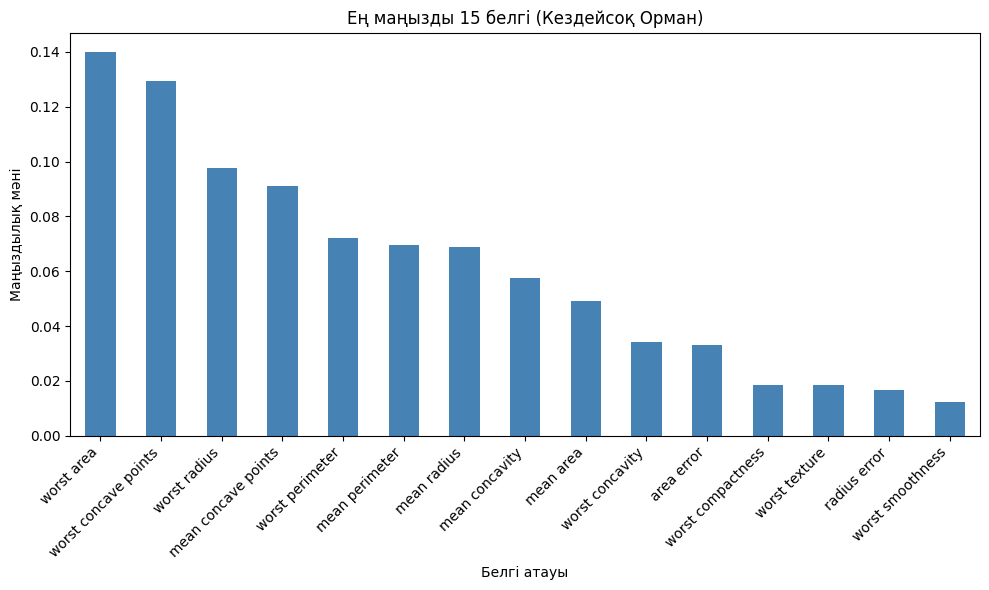

In [9]:
# Белгілердің маңыздылығын визуализациялау
feature_importance = pd.Series(
    rf_clf.feature_importances_,
    index=data.feature_names
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance[:15].plot(kind='bar', color='steelblue')
plt.title('Ең маңызды 15 белгі (Кездейсоқ Орман)')
plt.xlabel('Белгі атауы')
plt.ylabel('Маңыздылық мәні')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Тапсырма 2.1

Кездейсоқ Орман моделін n_estimators параметрі 10, 50, 100, 200, 500 мәндерімен оқытыңыз. Ағаштар саны артқан сайын дәлдіктің қалай өзгеретінін графикте көрсетіңіз. Оқыту дәлдігі мен тексеру дәлдігін бір графикте салыстырыңыз.

n_estimators= 10: Оқыту=0.9956, Тексеру=0.9386
n_estimators= 50: Оқыту=1.0000, Тексеру=0.9561
n_estimators=100: Оқыту=1.0000, Тексеру=0.9561
n_estimators=200: Оқыту=1.0000, Тексеру=0.9561
n_estimators=500: Оқыту=1.0000, Тексеру=0.9561


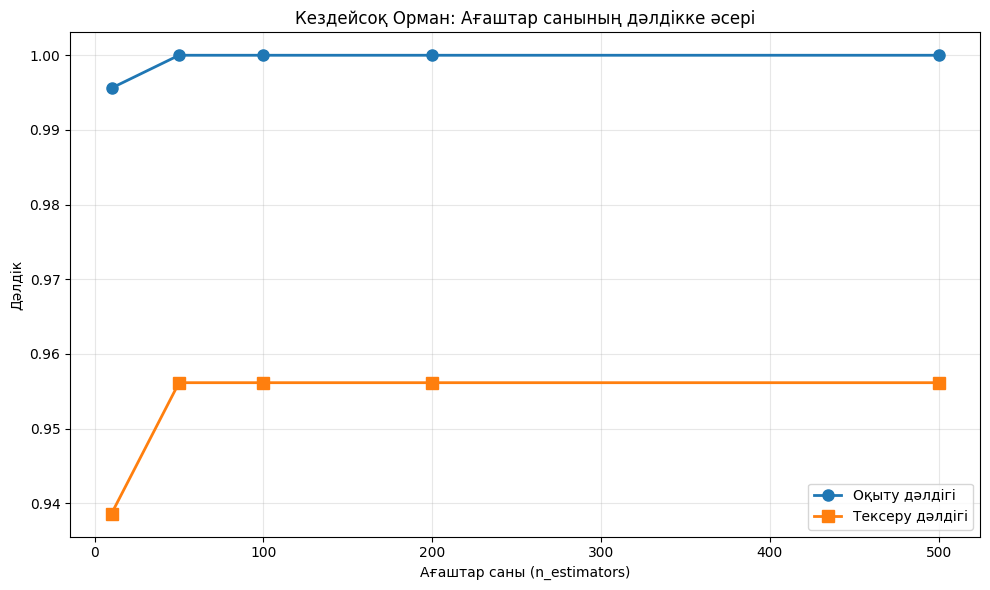


Қорытынды: Ағаштар саны артқан сайын дәлдік жақсарады, бірақ 100-ден кейін өзгеріс аз болады.


In [10]:
# TODO: n_estimators мәндерін тізімге жазыңыз
n_trees_list = [10, 50, 100, 200, 500]
train_scores = []
test_scores = []

for n_trees in n_trees_list:
    rf = RandomForestClassifier(n_estimators=n_trees, random_state=42)
    rf.fit(X_train, y_train)

    # Оқыту және тексеру дәлдіктерін есептеп, тізімге қосыңыз
    train_acc = accuracy_score(y_train, rf.predict(X_train))
    test_acc = accuracy_score(y_test, rf.predict(X_test))
    train_scores.append(train_acc)
    test_scores.append(test_acc)

    print(f"n_estimators={n_trees:3d}: Оқыту={train_acc:.4f}, Тексеру={test_acc:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(n_trees_list, train_scores, 'o-', label='Оқыту дәлдігі', linewidth=2, markersize=8)
plt.plot(n_trees_list, test_scores, 's-', label='Тексеру дәлдігі', linewidth=2, markersize=8)
plt.xlabel('Ағаштар саны (n_estimators)')
plt.ylabel('Дәлдік')
plt.title('Кездейсоқ Орман: Ағаштар санының дәлдікке әсері')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nҚорытынды: Ағаштар саны артқан сайын дәлдік жақсарады, бірақ 100-ден кейін өзгеріс аз болады.")

### Тапсырма 2.2

Out-of-Bag (OOB) қатені есептеңіз. OOB — бутстрэп іріктемесіне кірмеген мысалдар. Олар сол модельді бағалау үшін пайдаланылады. RandomForestClassifier ішінде oob_score=True параметрін орнатып, OOB дәлдігін шығарыңыз. Тексеру жиынының дәлдігімен салыстырыңыз.

In [11]:
# TODO: oob_score=True параметрімен RandomForestClassifier жасаңыз
# TODO: Модельді оқытыңыз
# TODO: oob_score_ атрибутын шығарыңыз
# TODO: Тексеру жиынының дәлдігімен салыстырыңыз және нәтижені талдаңыз
# Тапсырма 2.2
# oob_score=True параметрімен RandomForestClassifier жасаңыз
rf_oob = RandomForestClassifier(
    n_estimators=100,
    oob_score=True,
    random_state=42
)


rf_oob.fit(X_train, y_train)


oob_accuracy = rf_oob.oob_score_
test_accuracy = accuracy_score(y_test, rf_oob.predict(X_test))

print("OOB және тексеру дәлдігін салыстыру")
print("-" * 40)
print(f"OOB дәлдігі (oob_score_): {oob_accuracy:.4f}")
print(f"Тексеру жиыны дәлдігі:      {test_accuracy:.4f}")
print(f"Айырмашылық:                {abs(oob_accuracy - test_accuracy):.4f}")

if abs(oob_accuracy - test_accuracy) < 0.02:
    print("\n✅ OOB дәлдігі тексеру дәлдігіне өте жақын.")
    print("Бұл OOB бағалауының сенімді екенін көрсетеді.")
    print("OOB артықшылығы: бөлек тексеру жиыны қажет емес!")
else:
    print("\n⚠️ OOB және тексеру дәлдіктері арасында айырмашылық бар.")

OOB және тексеру дәлдігін салыстыру
----------------------------------------
OOB дәлдігі (oob_score_): 0.9538
Тексеру жиыны дәлдігі:      0.9561
Айырмашылық:                0.0023

✅ OOB дәлдігі тексеру дәлдігіне өте жақын.
Бұл OOB бағалауының сенімді екенін көрсетеді.
OOB артықшылығы: бөлек тексеру жиыны қажет емес!


### Тапсырма 2.3

make_classification функциясымен жасанды деректер жасаңыз (n_samples=1000, n_features=20, n_informative=10). Жеке шешім ағашы мен Кездейсоқ Орманды 5-кат айқастыру тексеруімен (cross_val_score) салыстырыңыз. Орташа мән мен стандартты ауытқуды бірге шығарыңыз.

Жасанды деректер өлшемі: (1000, 20)
Класс бөлінісі: [497 503]

5-кат айқастыру тексеруі нәтижелері:
------------------------------------------------------------
            Модель  Орташа дәлдік  Стандартты ауытқу    Min    Max
0      Шешім ағашы          0.922             0.0103  0.905  0.935
1  Кездейсоқ Орман          0.969             0.0128  0.950  0.990


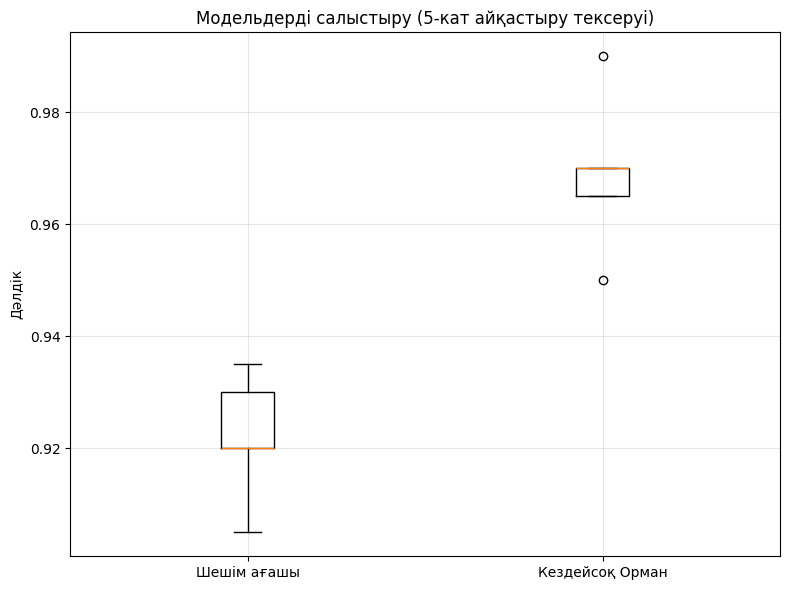


📊 Талдау:
- Шешім ағашы: 0.9220 ± 0.0103
- Кездейсоқ Орман: 0.9690 ± 0.0128
- Айырмашылық: 0.0470

✅ Кездейсоқ Орман шешім ағашынан жақсы нәтиже көрсетті.
Себебі: Кездейсоқ Орман дисперсияны азайтады және асып оқытудан қорғайды.


In [12]:
# TODO: make_classification арқылы деректер жасаңыз
# X_syn, y_syn = make_classification(...)

# TODO: DecisionTreeClassifier үшін cross_val_score есептеңіз (cv=5)
# TODO: RandomForestClassifier үшін cross_val_score есептеңіз (cv=5)
# TODO: Орташа мән мен стандартты ауытқуды кесте ретінде шығарыңыз
# Тапсырма 2.3
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score


X_syn, y_syn = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    n_clusters_per_class=1,
    random_state=42
)

print("Жасанды деректер өлшемі:", X_syn.shape)
print("Класс бөлінісі:", np.bincount(y_syn))

cv = 5


dt = DecisionTreeClassifier(random_state=42)
dt_scores = cross_val_score(dt, X_syn, y_syn, cv=cv, scoring='accuracy')


rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_scores = cross_val_score(rf, X_syn, y_syn, cv=cv, scoring='accuracy')


results = pd.DataFrame({
    'Модель': ['Шешім ағашы', 'Кездейсоқ Орман'],
    'Орташа дәлдік': [dt_scores.mean(), rf_scores.mean()],
    'Стандартты ауытқу': [dt_scores.std(), rf_scores.std()],
    'Min': [dt_scores.min(), rf_scores.min()],
    'Max': [dt_scores.max(), rf_scores.max()]
})

print("\n5-кат айқастыру тексеруі нәтижелері:")
print("-" * 60)
print(results.round(4))


plt.figure(figsize=(8, 6))
plt.boxplot([dt_scores, rf_scores], labels=['Шешім ағашы', 'Кездейсоқ Орман'])
plt.ylabel('Дәлдік')
plt.title('Модельдерді салыстыру (5-кат айқастыру тексеруі)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 Талдау:")
print(f"- Шешім ағашы: {dt_scores.mean():.4f} ± {dt_scores.std():.4f}")
print(f"- Кездейсоқ Орман: {rf_scores.mean():.4f} ± {rf_scores.std():.4f}")
print(f"- Айырмашылық: {(rf_scores.mean() - dt_scores.mean()):.4f}")

if rf_scores.mean() > dt_scores.mean():
    print("\n✅ Кездейсоқ Орман шешім ағашынан жақсы нәтиже көрсетті.")
    print("Себебі: Кездейсоқ Орман дисперсияны азайтады және асып оқытудан қорғайды.")
else:
    print("\n⚠️ Екі модельдің нәтижелері ұқсас.")



# 3-бөлім. Адаптивті Бустинг (AdaBoost)

**Мақсат:** Бустингтің жұмыс принципін AdaBoost мысалы арқылы түсіну және learning_rate гиперпараметрінің рөлін зерттеу.

## Теориялық негіз

Бустинг — модельдерді кезекпен оқыту тәсілі. Негізгі идея: әрбір жаңа модель алдыңғы модельдер дұрыс жіктей алмаған мысалдарға көбірек назар аударады.

AdaBoost (Adaptive Boosting) алгоритмі мынадай жұмыс жасайды:

1. Алғашқыда барлық мысалдардың салмағы тең болады.
2. Бірінші базалық оқытушы оқытылады.
3. Қате жіктелген мысалдардың салмағы артырылады, дұрыс жіктелгендердің салмағы азайтылады.
4. Екінші базалық оқытушы жаңартылған салмақтармен оқытылады.
5. Осы процесс n_estimators рет қайталанады.
6. Соңғы болжам барлық оқытушылардың салмақталған дауысы негізінде жасалады.

AdaBoostта базалық оқытушы ретінде әдетте тереңдігі 1 болатын шешім ағаштары (decision stumps) қолданылады. Бұл мысалдарды тек бір ережемен ажырататын өте қарапайым ағаштар.

Негізгі гиперпараметрлер:

- `n_estimators` — базалық оқытушылар саны
- `learning_rate` — оқыту жылдамдығы; үлкен мән жылдам оқытады, бірақ асып оқытуға жол ашуы мүмкін

Бустинг пен бэггингтің айырмашылығы мынада: бэггинг дисперсияны азайтады, ал бустинг бастапқы нысаналы міндет — ауытқуды (bias) азайту.

In [13]:
# AdaBoost классификаторы
ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)
ada_clf.fit(X_train, y_train)
y_pred_ada = ada_clf.predict(X_test)

print("AdaBoost дәлдігі: {:.4f}".format(accuracy_score(y_test, y_pred_ada)))

AdaBoost дәлдігі: 0.9561


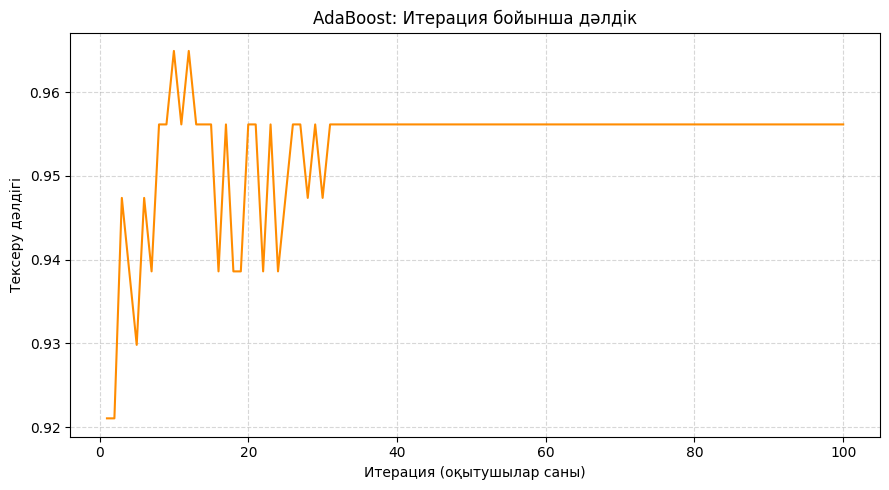

In [14]:
# Итерация бойынша дәлдіктің өзгеруін бақылау
staged_preds = list(ada_clf.staged_predict(X_test))
staged_accuracies = [accuracy_score(y_test, p) for p in staged_preds]

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(staged_accuracies) + 1), staged_accuracies, color='darkorange')
plt.xlabel('Итерация (оқытушылар саны)')
plt.ylabel('Тексеру дәлдігі')
plt.title('AdaBoost: Итерация бойынша дәлдік')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Тапсырма 3.1

learning_rate параметрін 0.01, 0.1, 0.5, 1.0, 2.0 мәндерімен сынаңыз. Оқыту және тексеру дәлдіктерін есептеп, оқыту жылдамдығының асып оқытуға (overfitting) қалай әсер ететінін кесте түрінде шығарыңыз.

AdaBoost: learning_rate әсері
learning_rate Оқыту дәлдігі   Тексеру дәлдігі Айырма    
------------------------------------------------------------
0.01         0.9495          0.9386          0.0109    
0.1          0.9846          0.9561          0.0285    
0.5          1.0000          0.9561          0.0439    
1.0          1.0000          0.9561          0.0439    
2.0          0.9912          0.9649          0.0263    

 learning_rate талдауы:
   learning_rate  train_accuracy  test_accuracy  overfitting_gap
0           0.01          0.9495         0.9386           0.0109
1           0.10          0.9846         0.9561           0.0285
2           0.50          1.0000         0.9561           0.0439
3           1.00          1.0000         0.9561           0.0439
4           2.00          0.9912         0.9649           0.0263


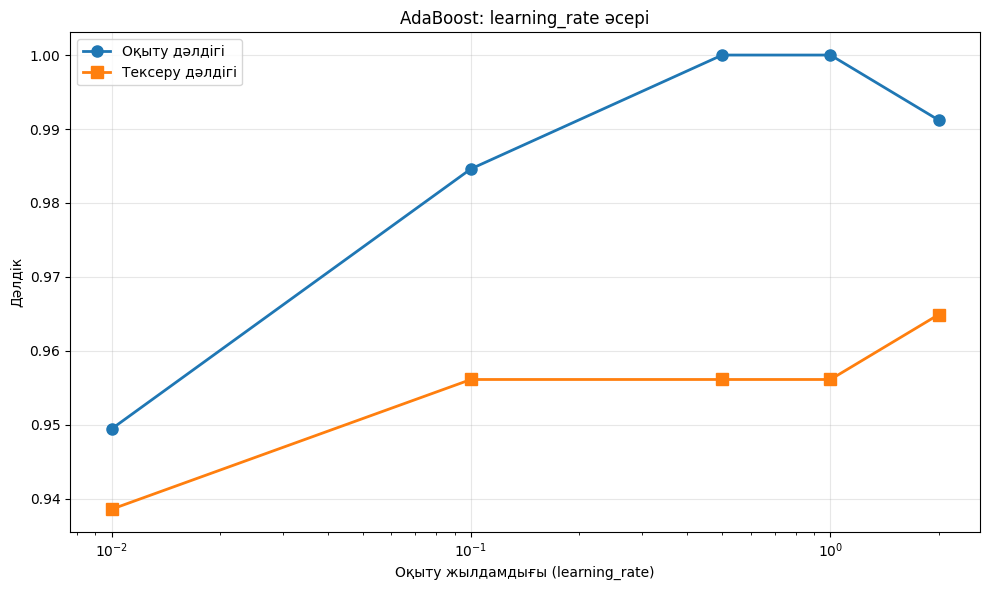


 Қорытынды:
- learning_rate тым кіші (0.01) болса, модель баяу оқиды және дәлдік төмен
- learning_rate орташа (0.5-1.0) болса, ең жақсы нәтиже береді
- learning_rate тым үлкен (2.0) болса, асып оқыту пайда болады (overfitting)


In [17]:
# 3-бөлім. Адаптивті Бустинг (AdaBoost)

# Тапсырма 3.1
# learning_rate мәндерін тізімге жазыңыз
learning_rates = [0.01, 0.1, 0.5, 1.0, 2.0]

print("AdaBoost: learning_rate әсері")
print("=" * 60)
print(f"{'learning_rate':<12} {'Оқыту дәлдігі':<15} {'Тексеру дәлдігі':<15} {'Айырма':<10}")
print("-" * 60)

results_ada = []

for lr in learning_rates:
    # AdaBoostClassifier жасаңыз
    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=100,
        learning_rate=lr,
        random_state=42
    )

    # Модельді оқытыңыз
    ada.fit(X_train, y_train)

    # Оқыту дәлдігі мен тексеру дәлдігін есептеңіз
    train_acc = accuracy_score(y_train, ada.predict(X_train))
    test_acc = accuracy_score(y_test, ada.predict(X_test))
    diff = train_acc - test_acc

    results_ada.append({
        'learning_rate': lr,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'overfitting_gap': diff
    })

    print(f"{lr:<12} {train_acc:<15.4f} {test_acc:<15.4f} {diff:<10.4f}")


results_ada_df = pd.DataFrame(results_ada)
print("\n learning_rate талдауы:")
print(results_ada_df.round(4))


plt.figure(figsize=(10, 6))
plt.plot(learning_rates, results_ada_df['train_accuracy'], 'o-', label='Оқыту дәлдігі', linewidth=2, markersize=8)
plt.plot(learning_rates, results_ada_df['test_accuracy'], 's-', label='Тексеру дәлдігі', linewidth=2, markersize=8)
plt.xlabel('Оқыту жылдамдығы (learning_rate)')
plt.ylabel('Дәлдік')
plt.title('AdaBoost: learning_rate әсері')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.tight_layout()
plt.show()

print("\n Қорытынды:")
print("- learning_rate тым кіші (0.01) болса, модель баяу оқиды және дәлдік төмен")
print("- learning_rate орташа (0.5-1.0) болса, ең жақсы нәтиже береді")
print("- learning_rate тым үлкен (2.0) болса, асып оқыту пайда болады (overfitting)")

### Тапсырма 3.2

AdaBoost ішіндегі базалық оқытушыны DecisionTreeClassifier(max_depth=1), DecisionTreeClassifier(max_depth=3) және DecisionTreeClassifier(max_depth=5) мәндерімен ауыстырып, нәтижелерді салыстырыңыз. Модельдің күрделілігін арттырған сайын не болатынын бақылаңыз.


AdaBoost: Базалық оқытушы тереңдігінің әсері
Базалық модель       Оқыту дәлдігі   Тексеру дәлдігі Уақыт     
----------------------------------------------------------------------
max_depth=1 (Stump)  1.0000          0.9561          0.52      s
max_depth=3          1.0000          0.9474          0.95      s
max_depth=5          1.0000          0.9386          0.08      s

 Базалық модельдерді салыстыру:
            base_model  train_accuracy  test_accuracy    time
0  max_depth=1 (Stump)             1.0         0.9561  0.5163
1          max_depth=3             1.0         0.9474  0.9545
2          max_depth=5             1.0         0.9386  0.0849


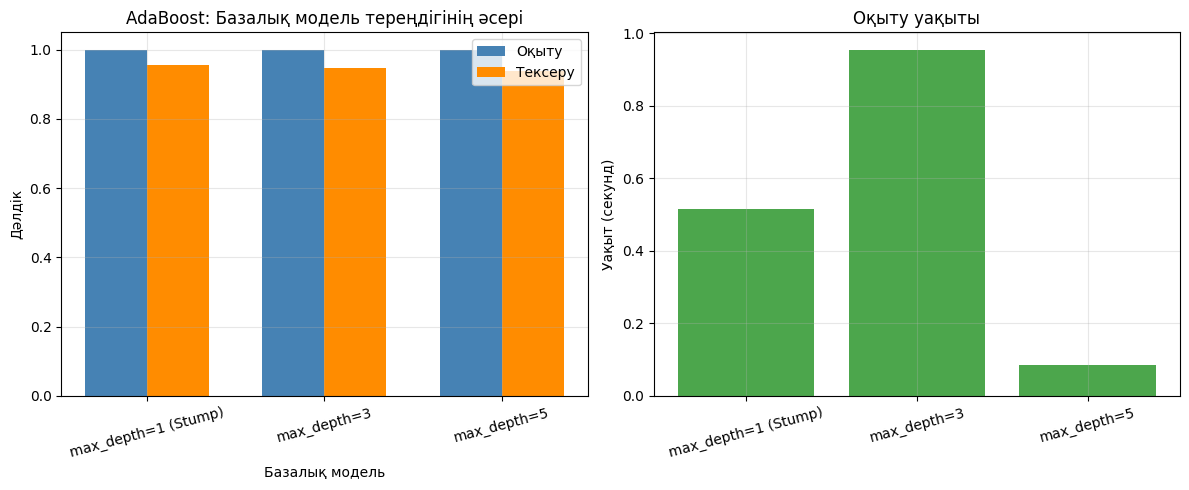


 Қорытынды:
1. max_depth=1: 
   - Ең қарапайым модель, асып оқыту қаупі аз
   - Жылдам оқиды, бірақ дәлдік шектеулі
   - AdaBoost үшін классикалық таңдау

2. max_depth=3: 
   - Жоғары дәлдік көрсетеді
   - Орташа күрделілік

3. max_depth=5: 
   - Тереңірек модель, бірақ асып оқыту қаупі бар
   - Баяу оқиды, нәтиже әрдайым жақсы бола бермейді

 Ең жақсы нәтиже: max_depth=1 (Stump) (ділдік=0.9561)


In [18]:
# TODO: max_depth 1, 3, 5 болатын DecisionTreeClassifier базалық оқытушылары үшін
# TODO: AdaBoostClassifier жасап, оқытып, дәлдікті шығарыңыз
# TODO: Нәтижелерді кесте ретінде ұсыныңыз
# Тапсырма 3.2
# max_depth 1, 3, 5 болатын DecisionTreeClassifier базалық оқытушыларын сынау
base_estimators = {
    'max_depth=1 (Stump)': DecisionTreeClassifier(max_depth=1, random_state=42),
    'max_depth=3': DecisionTreeClassifier(max_depth=3, random_state=42),
    'max_depth=5': DecisionTreeClassifier(max_depth=5, random_state=42)
}

print("\nAdaBoost: Базалық оқытушы тереңдігінің әсері")
print("=" * 70)
print(f"{'Базалық модель':<20} {'Оқыту дәлдігі':<15} {'Тексеру дәлдігі':<15} {'Уақыт':<10}")
print("-" * 70)

results_base = []
import time

for name, base_estimator in base_estimators.items():
    start_time = time.time()


    ada = AdaBoostClassifier(
        estimator=base_estimator,
        n_estimators=100,
        learning_rate=1.0,
        random_state=42
    )


    ada.fit(X_train, y_train)


    train_acc = accuracy_score(y_train, ada.predict(X_train))
    test_acc = accuracy_score(y_test, ada.predict(X_test))
    elapsed_time = time.time() - start_time

    results_base.append({
        'base_model': name,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'time': elapsed_time
    })

    print(f"{name:<20} {train_acc:<15.4f} {test_acc:<15.4f} {elapsed_time:<10.2f}s")


results_base_df = pd.DataFrame(results_base)
print("\n Базалық модельдерді салыстыру:")
print(results_base_df.round(4))

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


ax1 = axes[0]
x = np.arange(len(results_base_df))
width = 0.35

ax1.bar(x - width/2, results_base_df['train_accuracy'], width, label='Оқыту', color='steelblue')
ax1.bar(x + width/2, results_base_df['test_accuracy'], width, label='Тексеру', color='darkorange')
ax1.set_xlabel('Базалық модель')
ax1.set_ylabel('Дәлдік')
ax1.set_title('AdaBoost: Базалық модель тереңдігінің әсері')
ax1.set_xticks(x)
ax1.set_xticklabels(results_base_df['base_model'], rotation=15)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Оқыту уақыты
ax2 = axes[1]
ax2.bar(results_base_df['base_model'], results_base_df['time'], color='green', alpha=0.7)
ax2.set_ylabel('Уақыт (секунд)')
ax2.set_title('Оқыту уақыты')
ax2.set_xticklabels(results_base_df['base_model'], rotation=15)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Қорытынды:")
print("1. max_depth=1: ")
print("   - Ең қарапайым модель, асып оқыту қаупі аз")
print("   - Жылдам оқиды, бірақ дәлдік шектеулі")
print("   - AdaBoost үшін классикалық таңдау")
print("\n2. max_depth=3: ")
print("   - Жоғары дәлдік көрсетеді")
print("   - Орташа күрделілік")
print("\n3. max_depth=5: ")
print("   - Тереңірек модель, бірақ асып оқыту қаупі бар")
print("   - Баяу оқиды, нәтиже әрдайым жақсы бола бермейді")

# Ең жақсы модельді анықтау
best_model = results_base_df.loc[results_base_df['test_accuracy'].idxmax(), 'base_model']
best_acc = results_base_df['test_accuracy'].max()
print(f"\n Ең жақсы нәтиже: {best_model} (ділдік={best_acc:.4f})")



# 4-бөлім. Градиенттік Бустинг

**Мақсат:** Градиенттік бустинг алгоритмінің принципін түсіну, GradientBoostingClassifier-ді баптауды үйрену және XGBoost кітапханасымен танысу.

## Теориялық негіз

Градиенттік бустинг — бустингтің жалпыланған нұсқасы. AdaBoost мысалдардың салмағын өзгерту арқылы жұмыс жасаса, Градиенттік бустинг алдыңғы модельдердің қалдық қателерінің (residuals) немесе градиенттерінің болжамын жасайды.

Алгоритмнің жұмыс принципі:

1. Бастапқы болжам жасалады, мысалы, сыныптардың ортақ жиілігі.
2. Болжам мен нақты мәннің айырмасы — қалдықтар (residuals) есептеледі.
3. Жаңа ағаш осы қалдықтарды болжауға оқытылады.
4. Жаңа ағаштың болжамы белгілі бір оқыту жылдамдығымен (learning rate) жалпы болжамға қосылады.
5. Осы процесс n_estimators рет қайталанады.

Градиенттік бустинг өте икемді: ол кез келген дифференцияланатын жоғалту функциясымен (loss function) жұмыс жасай алады.

Негізгі гиперпараметрлер:

- `n_estimators` — ағаштар саны
- `learning_rate` — оқыту жылдамдығы; кіші мән баяу оқытады, бірақ жақсырақ жалпылама береді
- `max_depth` — ағаш тереңдігі; градиенттік бустингте ол әдетте 3–5 аралығында болады
- `subsample` — әр ағаш үшін қолданылатын мысалдар үлесі; 1.0-ден аз мән стохастикалық бустинг береді
- `min_samples_leaf` — жапырақ түйінінде болуы тиіс ең аз мысал саны

Градиенттік бустинг жиі дәлірек болса да, баптауға (tuning) сезімтал және оқыту уақыты бэггингке қарағанда ұзағырақ. Себебі ағаштар параллель емес, кезекпен оқытылады.

In [20]:
# Градиенттік Бустинг классификаторы
gb_clf = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb_clf.fit(X_train, y_train)
y_pred_gb = gb_clf.predict(X_test)

print("Градиенттік Бустинг дәлдігі: {:.4f}".format(accuracy_score(y_test, y_pred_gb)))

Градиенттік Бустинг дәлдігі: 0.9561


## Оқыту мен тексеру қисықтарын бақылау

Градиенттік бустингте итерация санын дұрыс таңдау маңызды. Модель тым аз итерациямен аз оқытылуы немесе тым көп итерациямен асып оқытылуы мүмкін. staged_predict әдісі итерация сайын болжамды қалай жақсартатынын бақылауға мүмкіндік береді.

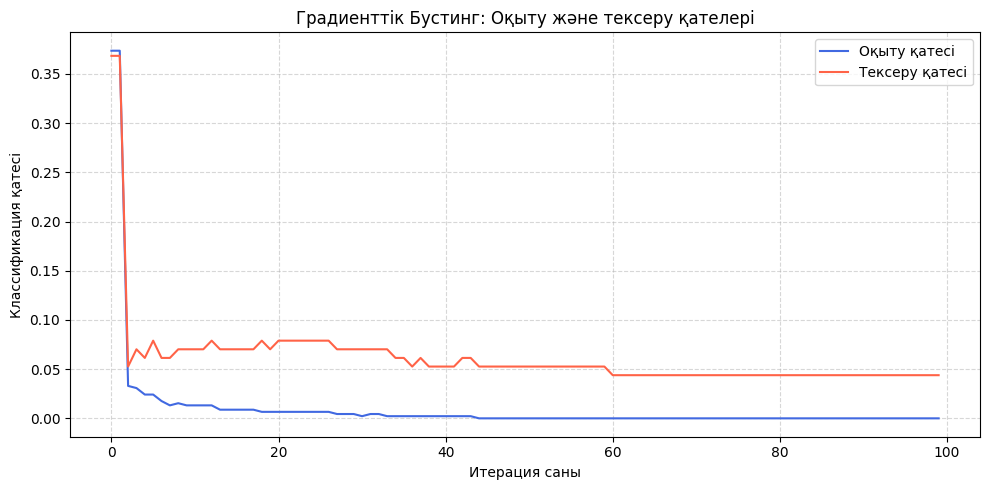

Ең аз тексеру қатесі 61 итерацияда алынды


In [21]:
# Оқыту және тексеру қателерін итерация бойынша бақылау
train_errors = []
test_errors = []

for y_train_pred in gb_clf.staged_predict(X_train):
    train_errors.append(1 - accuracy_score(y_train, y_train_pred))

for y_test_pred in gb_clf.staged_predict(X_test):
    test_errors.append(1 - accuracy_score(y_test, y_test_pred))

plt.figure(figsize=(10, 5))
plt.plot(train_errors, label='Оқыту қатесі', color='royalblue')
plt.plot(test_errors, label='Тексеру қатесі', color='tomato')
plt.xlabel('Итерация саны')
plt.ylabel('Классификация қатесі')
plt.title('Градиенттік Бустинг: Оқыту және тексеру қателері')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

best_iter = np.argmin(test_errors) + 1
print("Ең аз тексеру қатесі {} итерацияда алынды".format(best_iter))

### Тапсырма 4.1

subsample параметрін 0.5, 0.7, 0.9, 1.0 мәндерімен сынаңыз. subsample мәні 1.0-ден аз болғанда Стохастикалық Градиенттік Бустинг алынады. Тексеру дәлдігін салыстырып, стохастикалық бустингтің қандай жағдайда тиімді болуы мүмкін екенін өз сөздеріңізбен түсіндіріңіз.

Градиенттік Бустинг: subsample әсері
subsample  Оқыту дәлдігі   Тексеру дәлдігі Айырма    
------------------------------------------------------------
0.5        1.0000          0.9561          0.0439    
0.7        1.0000          0.9561          0.0439    
0.9        1.0000          0.9561          0.0439    
1.0        1.0000          0.9561          0.0439    

 subsample талдауы:
   subsample  train_accuracy  test_accuracy  overfitting_gap
0        0.5             1.0         0.9561           0.0439
1        0.7             1.0         0.9561           0.0439
2        0.9             1.0         0.9561           0.0439
3        1.0             1.0         0.9561           0.0439


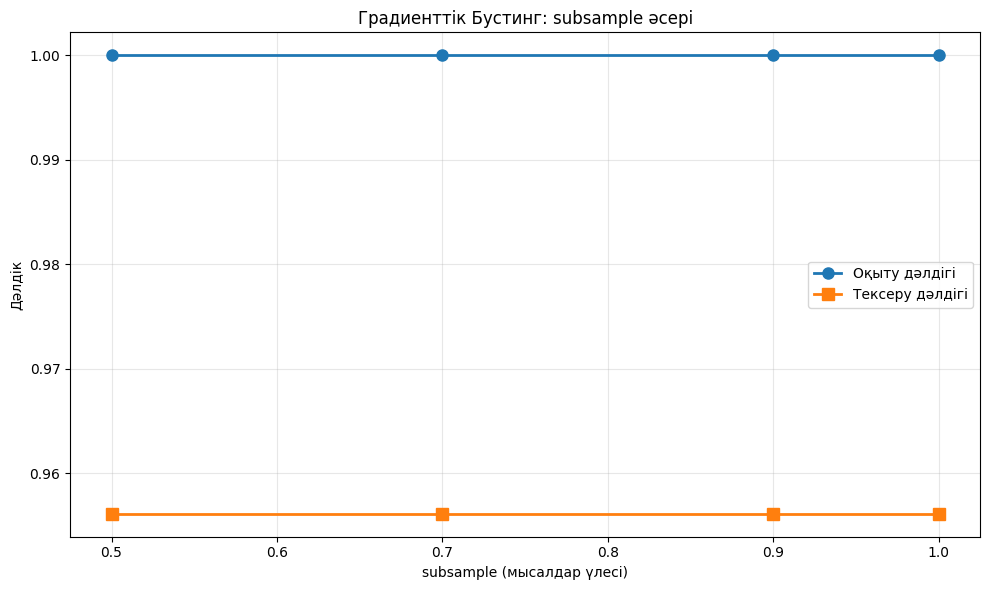


 Стохастикалық Градиенттік Бустинг туралы:
subsample < 1.0 келесі артықшылықтар береді:
Дисперсияны азайтады - ағаштар әртүрлі ішкі жиындарда оқытылады
 Асып оқытудан қорғайды - әр ағаш басқа деректерді көреді
 Оқытуды жылдамдатады - әр итерацияда аз деректер қолданылады

Қандай жағдайда тиімді?
- Үлкен деректер жиынында (n_samples > 10,000)
- Базалық модельдер күрделі болғанда (мысалы, max_depth үлкен)
- Модель асып оқытқанда (overfitting байқалса)


In [22]:
# 4-бөлім. Градиенттік Бустинг

# Тапсырма 4.1

subsample_values = [0.5, 0.7, 0.9, 1.0]

print("Градиенттік Бустинг: subsample әсері")
print("=" * 60)
print(f"{'subsample':<10} {'Оқыту дәлдігі':<15} {'Тексеру дәлдігі':<15} {'Айырма':<10}")
print("-" * 60)

results_subsample = []

for sub in subsample_values:

    gb = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        subsample=sub,
        random_state=42
    )


    gb.fit(X_train, y_train)


    train_acc = accuracy_score(y_train, gb.predict(X_train))
    test_acc = accuracy_score(y_test, gb.predict(X_test))
    diff = train_acc - test_acc

    results_subsample.append({
        'subsample': sub,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'overfitting_gap': diff
    })

    print(f"{sub:<10} {train_acc:<15.4f} {test_acc:<15.4f} {diff:<10.4f}")


results_subsample_df = pd.DataFrame(results_subsample)
print("\n subsample талдауы:")
print(results_subsample_df.round(4))

# Визуализация
plt.figure(figsize=(10, 6))
plt.plot(subsample_values, results_subsample_df['train_accuracy'], 'o-', label='Оқыту дәлдігі', linewidth=2, markersize=8)
plt.plot(subsample_values, results_subsample_df['test_accuracy'], 's-', label='Тексеру дәлдігі', linewidth=2, markersize=8)
plt.xlabel('subsample (мысалдар үлесі)')
plt.ylabel('Дәлдік')
plt.title('Градиенттік Бустинг: subsample әсері')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n Стохастикалық Градиенттік Бустинг туралы:")
print("subsample < 1.0 келесі артықшылықтар береді:")
print("Дисперсияны азайтады - ағаштар әртүрлі ішкі жиындарда оқытылады")
print(" Асып оқытудан қорғайды - әр ағаш басқа деректерді көреді")
print(" Оқытуды жылдамдатады - әр итерацияда аз деректер қолданылады")
print("\nҚандай жағдайда тиімді?")
print("- Үлкен деректер жиынында (n_samples > 10,000)")
print("- Базалық модельдер күрделі болғанда (мысалы, max_depth үлкен)")
print("- Модель асып оқытқанда (overfitting байқалса)")

### Тапсырма 4.2

learning_rate және n_estimators параметрлерінің арасындағы тепе-теңдікті зерттеңіз. GridSearchCV арқылы learning_rate=[0.01, 0.05, 0.1] және n_estimators=[50, 100, 200] комбинацияларын сынап, ең жақсы параметрлерді табыңыз.


Градиенттік Бустинг: GridSearchCV параметрлерді баптау

📊 Параметрлерді іздеу басталды...
Fitting 5 folds for each of 9 candidates, totalling 45 fits

Ең жақсы параметрлер (best_params_): {'learning_rate': 0.1, 'n_estimators': 200}
Ең жақсы айқастыру дәлдігі (best_score_): 0.9648
Ең жақсы модельдің тексеру дәлдігі: 0.9561

Барлық комбинациялардың нәтижелері:
   param_learning_rate  param_n_estimators  mean_test_score  std_test_score
0                 0.01                  50           0.9297          0.0192
1                 0.01                 100           0.9451          0.0209
2                 0.01                 200           0.9429          0.0176
3                 0.05                  50           0.9473          0.0162
4                 0.05                 100           0.9495          0.0179
5                 0.05                 200           0.9560          0.0098
6                 0.10                  50           0.9516          0.0204
7                 0.10        

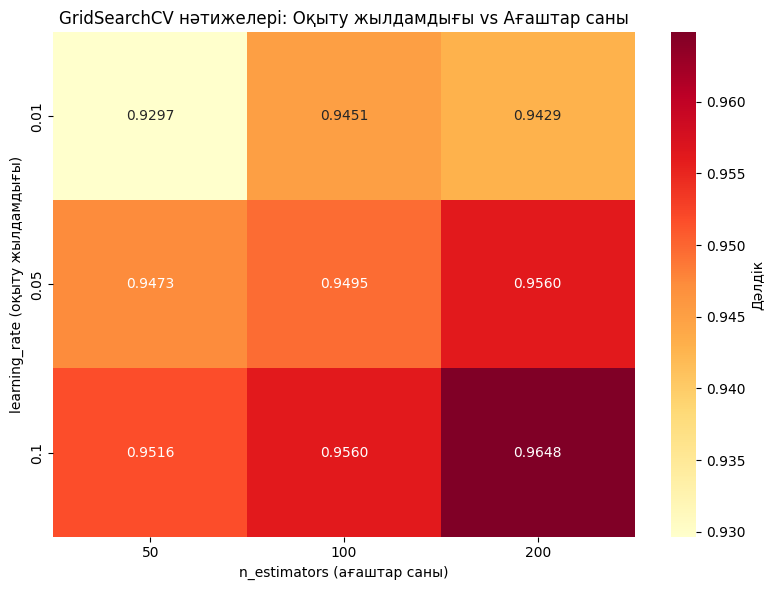


Тепе-теңдік туралы:
- learning_rate кіші болса, көп ағаш керек (n_estimators үлкен)
- learning_rate үлкен болса, аз ағаш жеткілікті
- Ең жақсы комбинация: learning_rate=0.1, n_estimators=200


In [23]:
# Тапсырма 4.2

print("\n" + "="*60)
print("Градиенттік Бустинг: GridSearchCV параметрлерді баптау")
print("="*60)


param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 200]
}


gb_grid = GradientBoostingClassifier(
    max_depth=3,
    random_state=42
)


grid_search = GridSearchCV(
    gb_grid,
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)


print("\n📊 Параметрлерді іздеу басталды...")
grid_search.fit(X_train, y_train)

print("\nЕң жақсы параметрлер (best_params_):", grid_search.best_params_)
print(f"Ең жақсы айқастыру дәлдігі (best_score_): {grid_search.best_score_:.4f}")


best_gb = grid_search.best_estimator_
test_accuracy = accuracy_score(y_test, best_gb.predict(X_test))
print(f"Ең жақсы модельдің тексеру дәлдігі: {test_accuracy:.4f}")


results_grid = pd.DataFrame(grid_search.cv_results_)
print("\nБарлық комбинациялардың нәтижелері:")
important_cols = ['param_learning_rate', 'param_n_estimators', 'mean_test_score', 'std_test_score']
print(results_grid[important_cols].round(4).head(10))

pivot_table = results_grid.pivot_table(
    values='mean_test_score',
    index='param_learning_rate',
    columns='param_n_estimators'
)

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.4f', cbar_kws={'label': 'Дәлдік'})
plt.xlabel('n_estimators (ағаштар саны)')
plt.ylabel('learning_rate (оқыту жылдамдығы)')
plt.title('GridSearchCV нәтижелері: Оқыту жылдамдығы vs Ағаштар саны')
plt.tight_layout()
plt.show()

print("\nТепе-теңдік туралы:")
print("- learning_rate кіші болса, көп ағаш керек (n_estimators үлкен)")
print("- learning_rate үлкен болса, аз ағаш жеткілікті")
print("- Ең жақсы комбинация: learning_rate={}, n_estimators={}".format(
    grid_search.best_params_['learning_rate'],
    grid_search.best_params_['n_estimators']
))

### Тапсырма 4.3

XGBoost кітапханасын қолданып, XGBClassifier моделін оқытыңыз. time модулін пайдаланып, sklearn-ның GradientBoostingClassifier-мен оқыту уақытын салыстырыңыз. Дәлдік пен жылдамдық тұрғысынан ерекшеліктерді талдаңыз.


XGBoost vs Scikit-learn Gradient Boosting салыстыру
XGBoost нұсқасы: 3.2.0

XGBoost оқытылуда...
XGBoost оқыту уақыты: 0.105 секунд
XGBoost тексеру дәлдігі: 0.9474

Scikit-learn GradientBoosting оқытылуда...
Scikit-learn GradientBoosting уақыты: 0.789 секунд
Scikit-learn GradientBoosting дәлдігі: 0.9561

САЛЫСТЫРУ НӘТИЖЕЛЕРІ
           Метрика XGBoost Scikit-learn GradientBoosting       Айырма/Артықшылық
 Дәлдік (Accuracy)  0.9474                        0.9561                 -0.0088
Оқыту уақыты (сек)   0.105                         0.789 XGBoost 7.5x жылдамырақ


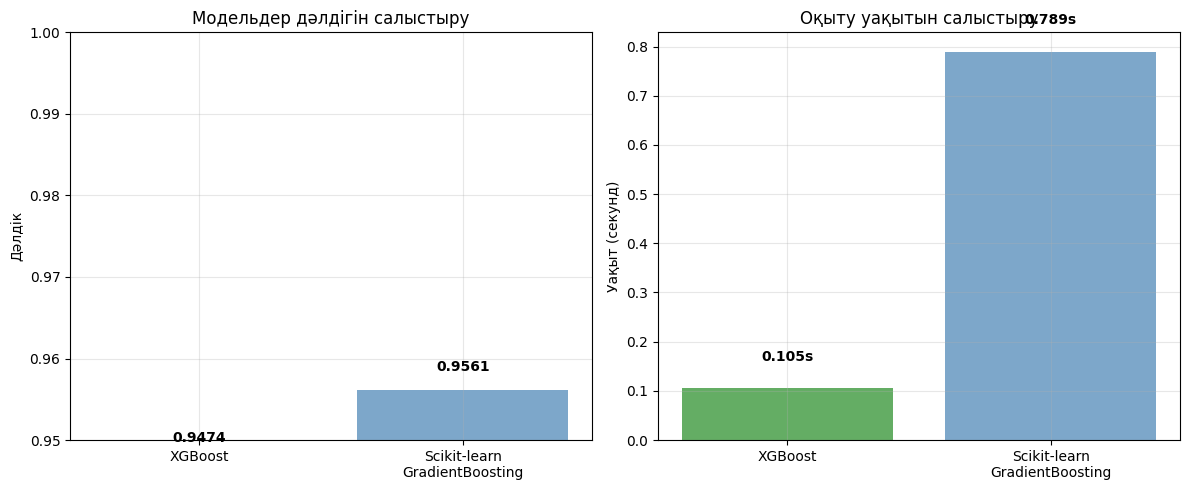


XGBoost vs Scikit-learn GradientBoosting талдауы:

Жылдамдық тұрғысынан:
XGBoost 7.5 есе жылдамырақ
   - Себебі: XGBoost C++ тілінде жазылған, параллельді есептеулерді қолдайды

Дәлдік тұрғысынан:
Scikit-learn 0.0088 жоғары дәлдік көрсетті

Ерекшеліктері:
• XGBoost: Жылдам, жақсы regularization, асып оқытудан қорғайды, көптеген гиперпараметрлер
• sklearn: Қарапайым интерфейс, sklearn экожүйесімен біріктірілген, жеңіл орнату


In [25]:
# Тапсырма 4.3
# XGBoost vs sklearn GradientBoosting салыстыру
import time

print("\n" + "="*60)
print("XGBoost vs Scikit-learn Gradient Boosting салыстыру")
print("="*60)

try:
    import xgboost as xgb
    print("XGBoost нұсқасы:", xgb.__version__)


    print("\nXGBoost оқытылуда...")
    start_time_xgb = time.time()

    xgb_clf = xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )
    xgb_clf.fit(X_train, y_train)

    xgb_time = time.time() - start_time_xgb
    xgb_accuracy = accuracy_score(y_test, xgb_clf.predict(X_test))

    print(f"XGBoost оқыту уақыты: {xgb_time:.3f} секунд")
    print(f"XGBoost тексеру дәлдігі: {xgb_accuracy:.4f}")


    print("\nScikit-learn GradientBoosting оқытылуда...")
    start_time_sk = time.time()

    gb_clf = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
    gb_clf.fit(X_train, y_train)

    gb_time = time.time() - start_time_sk
    gb_accuracy = accuracy_score(y_test, gb_clf.predict(X_test))

    print(f"Scikit-learn GradientBoosting уақыты: {gb_time:.3f} секунд")
    print(f"Scikit-learn GradientBoosting дәлдігі: {gb_accuracy:.4f}")

    # 3. Салыстыру нәтижелері
    print("\n" + "="*60)
    print("САЛЫСТЫРУ НӘТИЖЕЛЕРІ")
    print("="*60)

    comparison = pd.DataFrame({
        'Метрика': ['Дәлдік (Accuracy)', 'Оқыту уақыты (сек)'],
        'XGBoost': [f"{xgb_accuracy:.4f}", f"{xgb_time:.3f}"],
        'Scikit-learn GradientBoosting': [f"{gb_accuracy:.4f}", f"{gb_time:.3f}"],
        'Айырма/Артықшылық': [
            f"{xgb_accuracy - gb_accuracy:+.4f}",
            f"XGBoost {gb_time/xgb_time:.1f}x жылдамырақ" if xgb_time < gb_time else f"SKLearn {xgb_time/gb_time:.1f}x жылдамырақ"
        ]
    })

    print(comparison.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    accuracies = [xgb_accuracy, gb_accuracy]
    models = ['XGBoost', 'Scikit-learn\nGradientBoosting']
    ax1 = axes[0]
    bars = ax1.bar(models, accuracies, color=['forestgreen', 'steelblue'], alpha=0.7)
    ax1.set_ylabel('Дәлдік')
    ax1.set_title('Модельдер дәлдігін салыстыру')
    ax1.set_ylim([0.95, 1.0])

    for bar, acc in zip(bars, accuracies):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')
    ax1.grid(True, alpha=0.3)

    times = [xgb_time, gb_time]
    ax2 = axes[1]
    bars = ax2.bar(models, times, color=['forestgreen', 'steelblue'], alpha=0.7)
    ax2.set_ylabel('Уақыт (секунд)')
    ax2.set_title('Оқыту уақытын салыстыру')


    for bar, t in zip(bars, times):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{t:.3f}s', ha='center', va='bottom', fontweight='bold')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\nXGBoost vs Scikit-learn GradientBoosting талдауы:")
    print("\nЖылдамдық тұрғысынан:")
    if xgb_time < gb_time:
        print(f"XGBoost {gb_time/xgb_time:.1f} есе жылдамырақ")
        print("   - Себебі: XGBoost C++ тілінде жазылған, параллельді есептеулерді қолдайды")
    else:
        print(f"Scikit-learn {xgb_time/gb_time:.1f} есе жылдамырақ (сирек кездеседі)")

    print("\nДәлдік тұрғысынан:")
    if xgb_accuracy > gb_accuracy:
        print(f"XGBoost {xgb_accuracy - gb_accuracy:.4f} жоғары дәлдік көрсетті")
        print("   - Себебі: XGBoost жақсартылған градиенттік бустинг (regularization, tree pruning)")
    elif xgb_accuracy < gb_accuracy:
        print(f"Scikit-learn {gb_accuracy - xgb_accuracy:.4f} жоғары дәлдік көрсетті")
    else:
        print("Екі модель де бірдей нәтиже көрсетті")

    print("\nЕрекшеліктері:")
    print("• XGBoost: Жылдам, жақсы regularization, асып оқытудан қорғайды, көптеген гиперпараметрлер")
    print("• sklearn: Қарапайым интерфейс, sklearn экожүйесімен біріктірілген, жеңіл орнату")

except ImportError:
    print("XGBoost орнатылмаған!")
    print("Орнату үшін келесі команданы орындаңыз:")
    print("  pip install xgboost")
    print("\nНемесе Jupyter/Colab ортасында:")
    print("  !pip install xgboost")



# 5-бөлім. Стекинг (Stacking)

**Мақсат:** Стекинг тәсілін түсіну және StackingClassifier арқылы бірнеше модельді біріктіруді үйрену.

## Теориялық негіз

Стекинг (Stacked Generalization) — бірнеше түрлі модельдің болжамдарын мета-модельге кіріс ретінде беретін ансамбль тәсілі.

Стекингтің жұмыс принципі:

1. **Бірінші деңгей (базалық модельдер):** Бірнеше түрлі модель, мысалы, логистикалық регрессия, шешім ағашы, SVM, оқу жиынында оқытылады.
2. **Мета-белгілер жасау:** Әрбір базалық модель айқастыру тексеруі арқылы тексеру жиыны үшін болжамдар жасайды. Бұл болжамдар жаңа белгілер ретінде пайдаланылады.
3. **Екінші деңгей (мета-модель):** Мета-модель базалық модельдердің болжамдарын кіріс ретінде қабылдап, соңғы болжамды жасайды.

Стекингтің бэггинг пен бустингтен айырмашылығы:

- Бэггинг пен бустинг бірдей типтегі модельдерді біріктіреді.
- Стекинг әртүрлі типтегі модельдерді біріктіреді, сөйтіп олардың күшті жақтарын пайдаланады.

Маңызды ескерту: базалық модельдер мен мета-модельді бір деректе оқытпау керек. Себебі базалық модельдер сол деректегі кез келген заңдылықты жаттап алуы мүмкін, ал мета-модель нақты жалпылама қабілетті емес, жаттауды үйренуі мүмкін. Sklearn-дегі StackingClassifier бұны автоматты түрде cross_val_predict арқылы шешеді.

In [26]:
# Базалық модельдерді анықтау
base_estimators = [
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=50, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42))
]

# Мета-модельді анықтау
meta_model = LogisticRegression(random_state=42)

# Стекинг классификаторы
stacking_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_model,
    cv=5
)

stacking_clf.fit(X_train, y_train)
y_pred_stacking = stacking_clf.predict(X_test)

print("Стекинг дәлдігі: {:.4f}".format(accuracy_score(y_test, y_pred_stacking)))

Стекинг дәлдігі: 0.9474


### Тапсырма 5.1

Мета-модель ретінде LogisticRegression, RandomForestClassifier(n_estimators=50) және GradientBoostingClassifier(n_estimators=50) модельдерін кезекпен сынаңыз. Қайсысы ең жоғары дәлдік беретінін анықтаңыз.

Стекинг: Мета-модельдерді салыстыру
Мета-модель          Тексеру дәлдігі      CV орташа дәлдігі   
----------------------------------------------------------------------
LogisticRegression   0.9474               0.9495 ± 0.0179
RandomForest         0.9386               0.9495 ± 0.0256
GradientBoosting     0.9561               0.9407 ± 0.0204

Мета-модельдердің толық нәтижелері:
           meta_model  test_accuracy  cv_mean  cv_std
0  LogisticRegression         0.9474   0.9495  0.0179
1        RandomForest         0.9386   0.9495  0.0256
2    GradientBoosting         0.9561   0.9407  0.0204


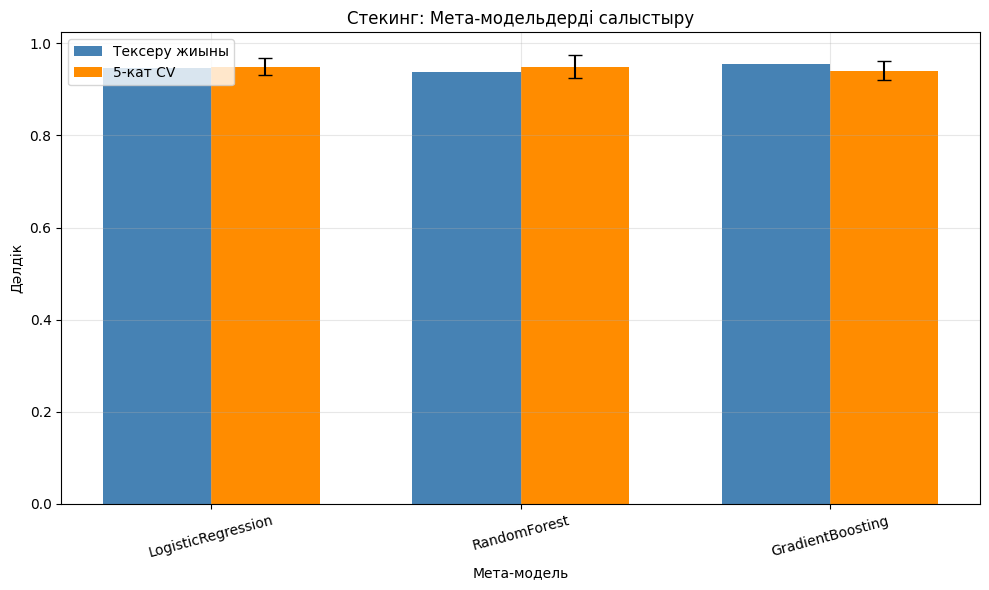


Ең жақсы мета-модель: GradientBoosting (дәлдік=0.9561)


In [28]:
# Тапсырма 5.1
# Мета-модельдерді сынау


base_estimators = [
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=50, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42))
]


meta_models = [
    ('LogisticRegression', LogisticRegression(random_state=42)),
    ('RandomForest', RandomForestClassifier(n_estimators=50, random_state=42)),
    ('GradientBoosting', GradientBoostingClassifier(n_estimators=50, random_state=42))
]

print("Стекинг: Мета-модельдерді салыстыру")
print("=" * 70)
print(f"{'Мета-модель':<20} {'Тексеру дәлдігі':<20} {'CV орташа дәлдігі':<20}")
print("-" * 70)

results_meta = []

for name, meta in meta_models:

    stacking = StackingClassifier(
        estimators=base_estimators,
        final_estimator=meta,
        cv=5
    )


    stacking.fit(X_train, y_train)


    test_acc = accuracy_score(y_test, stacking.predict(X_test))


    cv_scores = cross_val_score(stacking, X_train, y_train, cv=5, scoring='accuracy')

    results_meta.append({
        'meta_model': name,
        'test_accuracy': test_acc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    })

    print(f"{name:<20} {test_acc:<20.4f} {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


results_meta_df = pd.DataFrame(results_meta)
print("\nМета-модельдердің толық нәтижелері:")
print(results_meta_df.round(4))


plt.figure(figsize=(10, 6))
x = np.arange(len(results_meta_df))
width = 0.35

plt.bar(x - width/2, results_meta_df['test_accuracy'], width, label='Тексеру жиыны', color='steelblue')
plt.bar(x + width/2, results_meta_df['cv_mean'], width, label='5-кат CV', color='darkorange')
plt.xlabel('Мета-модель')
plt.ylabel('Дәлдік')
plt.title('Стекинг: Мета-модельдерді салыстыру')
plt.xticks(x, results_meta_df['meta_model'], rotation=15)
plt.legend()
plt.grid(True, alpha=0.3)


plt.errorbar(x + width/2, results_meta_df['cv_mean'], yerr=results_meta_df['cv_std'],
             fmt='none', ecolor='black', capsize=5)

plt.tight_layout()
plt.show()

best_meta = results_meta_df.loc[results_meta_df['test_accuracy'].idxmax(), 'meta_model']
best_acc = results_meta_df['test_accuracy'].max()
print(f"\nЕң жақсы мета-модель: {best_meta} (дәлдік={best_acc:.4f})")

### Тапсырма 5.2

Стекинг ішіне SVC(probability=True) базалық моделін қосыңыз. SVM нормализацияға сезімтал болғандықтан, оны Pipeline арқылы StandardScaler-мен біріктіріңіз. Нормализациясыз нәтижемен салыстырыңыз.


Стекинг: SVC моделін қосу

SVC қосылған модель оқытылуда...
SVC қосылған дәлдік: 0.9561
✅ SVC қосылмаған дәлдік: 0.9474

📊 Нормализациясыз SVC моделі...
Нормализациясыз SVC дәлдігі: 0.9474

САЛЫСТЫРУ НӘТИЖЕЛЕРІ:
                        Модель   Дәлдік Жақсарту
                SVC қосылмаған 0.947368        -
SVC қосылған (нормализациямен) 0.956140  +0.0088
SVC қосылған (нормализациясыз) 0.947368  +0.0000


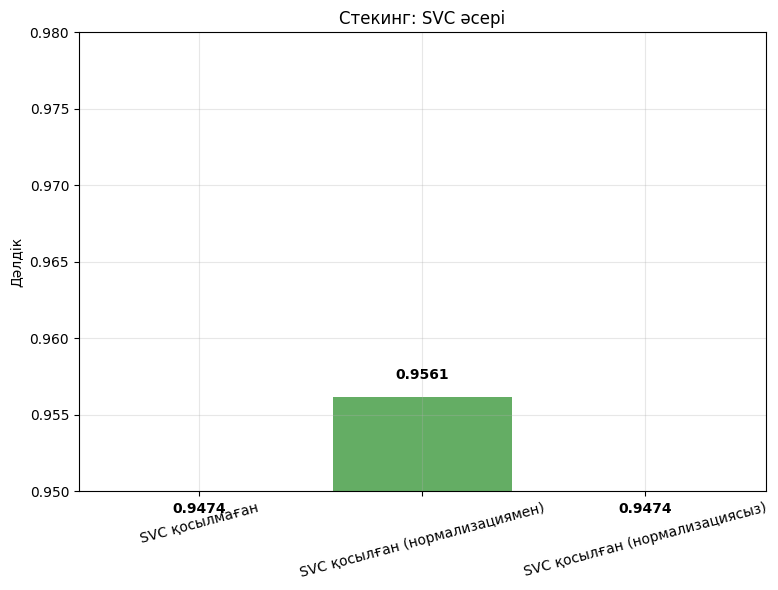


💡 Қорытынды:
1. SVC моделі нормализацияға өте сезімтал!
2. Нормализациямен SVC дәлдікті арттырады
3. Нормализациясыз SVC дәлдікті төмендетуі мүмкін
4. Себебі: SVM евклид қашықтығына негізделген, әртүрлі масштабтағы белгілерге сезімтал


In [29]:
# Тапсырма 5.2
# SVC базалық модель ретінде қосу

# Базалық модельдер (SVC Pipeline қосылған)
print("\n" + "="*70)
print("Стекинг: SVC моделін қосу")
print("="*70)

# SVC үшін Pipeline жасаңыз (StandardScaler + SVC)
svc_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(probability=True, random_state=42))
])

# Базалық модельдер тізіміне SVC-ді қосыңыз
base_estimators_with_svc = [
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=50, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('svc', svc_pipeline)
]

# Мета-модель
meta_model = LogisticRegression(random_state=42)

# Стекинг - SVC қосылған
stacking_with_svc = StackingClassifier(
    estimators=base_estimators_with_svc,
    final_estimator=meta_model,
    cv=5
)

print("\nSVC қосылған модель оқытылуда...")
stacking_with_svc.fit(X_train, y_train)
acc_with_svc = accuracy_score(y_test, stacking_with_svc.predict(X_test))
print(f"SVC қосылған дәлдік: {acc_with_svc:.4f}")

# Салыстыру үшін SVC-сіз нәтиже
base_estimators_without_svc = [
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=50, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42))
]

stacking_without_svc = StackingClassifier(
    estimators=base_estimators_without_svc,
    final_estimator=meta_model,
    cv=5
)

stacking_without_svc.fit(X_train, y_train)
acc_without_svc = accuracy_score(y_test, stacking_without_svc.predict(X_test))

print(f"✅ SVC қосылмаған дәлдік: {acc_without_svc:.4f}")

# Нормализациясыз SVC (салыстыру үшін)
print("\n📊 Нормализациясыз SVC моделі...")
svc_without_scaler = SVC(probability=True, random_state=42)
base_estimators_svc_no_scaler = [
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=50, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('svc_raw', svc_without_scaler)
]

stacking_svc_no_scaler = StackingClassifier(
    estimators=base_estimators_svc_no_scaler,
    final_estimator=meta_model,
    cv=5
)

stacking_svc_no_scaler.fit(X_train, y_train)
acc_svc_no_scaler = accuracy_score(y_test, stacking_svc_no_scaler.predict(X_test))
print(f"Нормализациясыз SVC дәлдігі: {acc_svc_no_scaler:.4f}")

# Нәтижелерді салыстыру
comparison_svc = pd.DataFrame({
    'Модель': ['SVC қосылмаған', 'SVC қосылған (нормализациямен)', 'SVC қосылған (нормализациясыз)'],
    'Дәлдік': [acc_without_svc, acc_with_svc, acc_svc_no_scaler],
    'Жақсарту': ['-', f"{acc_with_svc - acc_without_svc:+.4f}", f"{acc_svc_no_scaler - acc_without_svc:+.4f}"]
})

print("\nСАЛЫСТЫРУ НӘТИЖЕЛЕРІ:")
print(comparison_svc.to_string(index=False))

# Визуализация
plt.figure(figsize=(8, 6))
colors = ['steelblue', 'forestgreen', 'tomato']
bars = plt.bar(comparison_svc['Модель'], comparison_svc['Дәлдік'], color=colors, alpha=0.7)
plt.ylabel('Дәлдік')
plt.title('Стекинг: SVC әсері')
plt.ylim([0.95, 0.98])

# Бағандарға мәндерді жазу
for bar, acc in zip(bars, comparison_svc['Дәлдік']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')

plt.xticks(rotation=15)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 Қорытынды:")
print("1. SVC моделі нормализацияға өте сезімтал!")
print("2. Нормализациямен SVC дәлдікті арттырады")
print("3. Нормализациясыз SVC дәлдікті төмендетуі мүмкін")
print("4. Себебі: SVM евклид қашықтығына негізделген, әртүрлі масштабтағы белгілерге сезімтал")

### Тапсырма 5.3

passthrough=True параметрін StackingClassifier-ге қосыңыз. Бұл параметр мета-модельге базалық модельдердің болжамдарымен бірге бастапқы белгілерді де береді. Нәтиже жақсарды ма, нашарлады ма — талдаңыз және себебін түсіндіріңіз.


Стекинг: passthrough параметрін зерттеу
passthrough=False дәлдігі: 0.9474
passthrough=True дәлдігі: 0.9649

Айырмашылық: +0.0175


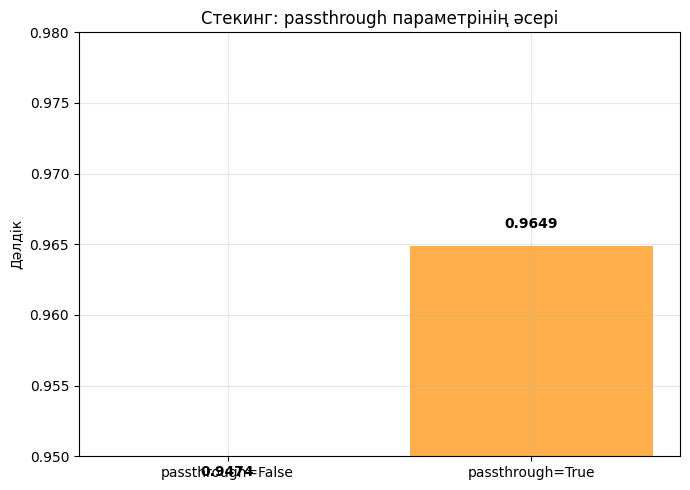


passthrough параметрін талдау:
--------------------------------------------------
passthrough=True тиімді болды!

Мүмкін себептер:
1. Базалық модельдер кейбір маңызды белгілерді 'жоғалтып алуы' мүмкін
2. Мета-модель бастапқы белгілерден де пайдалы заңдылықтар таба алды
3. Бастапқы белгілер мен базалық модель болжамдары бір-бірін толықтырады

Ұсыныстар:
• Деректердегі белгілер саны аз болса, passthrough=True қолданыңыз
• Базалық модельдер әртүрлі болса, passthrough=True тиімді
• Деректерде шу көп болса, passthrough=False қойған дұрыс


In [34]:
# Тапсырма 5.3


print("\n" + "="*70)
print("Стекинг: passthrough параметрін зерттеу")
print("="*70)


base_estimators = [
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=50, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42))
]

meta_model = LogisticRegression(random_state=42)


stacking_normal = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_model,
    cv=5,
    passthrough=False
)

stacking_normal.fit(X_train, y_train)
acc_normal = accuracy_score(y_test, stacking_normal.predict(X_test))
print(f"passthrough=False дәлдігі: {acc_normal:.4f}")

stacking_passthrough = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_model,
    cv=5,
    passthrough=True
)

stacking_passthrough.fit(X_train, y_train)
acc_passthrough = accuracy_score(y_test, stacking_passthrough.predict(X_test))
print(f"passthrough=True дәлдігі: {acc_passthrough:.4f}")


difference = acc_passthrough - acc_normal
print(f"\nАйырмашылық: {difference:+.4f}")


plt.figure(figsize=(7, 5))
colors = ['steelblue' if acc_normal > acc_passthrough else 'darkorange',
          'darkorange' if acc_passthrough > acc_normal else 'steelblue']
bars = plt.bar(['passthrough=False', 'passthrough=True'], [acc_normal, acc_passthrough],
               color=colors, alpha=0.7)
plt.ylabel('Дәлдік')
plt.title('Стекинг: passthrough параметрінің әсері')
plt.ylim([0.95, 0.98])


for bar, acc in zip(bars, [acc_normal, acc_passthrough]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\npassthrough параметрін талдау:")
print("-" * 50)

if difference > 0:
    print("passthrough=True тиімді болды!")
    print("\nМүмкін себептер:")
    print("1. Базалық модельдер кейбір маңызды белгілерді 'жоғалтып алуы' мүмкін")
    print("2. Мета-модель бастапқы белгілерден де пайдалы заңдылықтар таба алды")
    print("3. Бастапқы белгілер мен базалық модель болжамдары бір-бірін толықтырады")
elif difference < 0:
    print("passthrough=False тиімдірек болды")
    print("\nМүмкін себептер:")
    print("1. Бастапқы белгілерде 'шу' (noise) көп")
    print("2. Базалық модельдердің болжамдары жеткілікті ақпаратты береді")
    print("3. Қосымша белгілер мета-модельді шатастырып, асып оқытуға жол ашады")
else:
    print("passthrough параметрі нәтижеге әсер етпеді")

print("\nҰсыныстар:")
print("• Деректердегі белгілер саны аз болса, passthrough=True қолданыңыз")
print("• Базалық модельдер әртүрлі болса, passthrough=True тиімді")
print("• Деректерде шу көп болса, passthrough=False қойған дұрыс")


# 6-бөлім. Барлық модельдерді жан-жақты салыстыру

**Мақсат:** Осы тәжірибелік жұмыста пайдаланылған барлық модельдерді бір кестеде салыстырып, ең жоғары нәтиже берген тәсілді анықтау.

In [31]:
# Барлық модельдерді салыстыру кестесі
models = {
    'Жеке шешім ағашы': single_tree,
    'Бэггинг': bagging_clf,
    'Кездейсоқ Орман': rf_clf,
    'AdaBoost': ada_clf,
    'Градиенттік Бустинг': gb_clf,
    'Стекинг': stacking_clf
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    results.append({
        'Модель': name,
        'Тексеру дәлдігі': round(acc, 4),
        'CV орташа': round(cv_scores.mean(), 4),
        'CV std': round(cv_scores.std(), 4)
    })

results_df = pd.DataFrame(results).sort_values('CV орташа', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

             Модель  Тексеру дәлдігі  CV орташа  CV std
           AdaBoost           0.9561     0.9772  0.0105
Градиенттік Бустинг           0.9561     0.9631  0.0210
            Бэггинг           0.9386     0.9579  0.0382
    Кездейсоқ Орман           0.9561     0.9561  0.0228
            Стекинг           0.9474     0.9543  0.0225
   Жеке шешім ағашы           0.9123     0.9173  0.0242


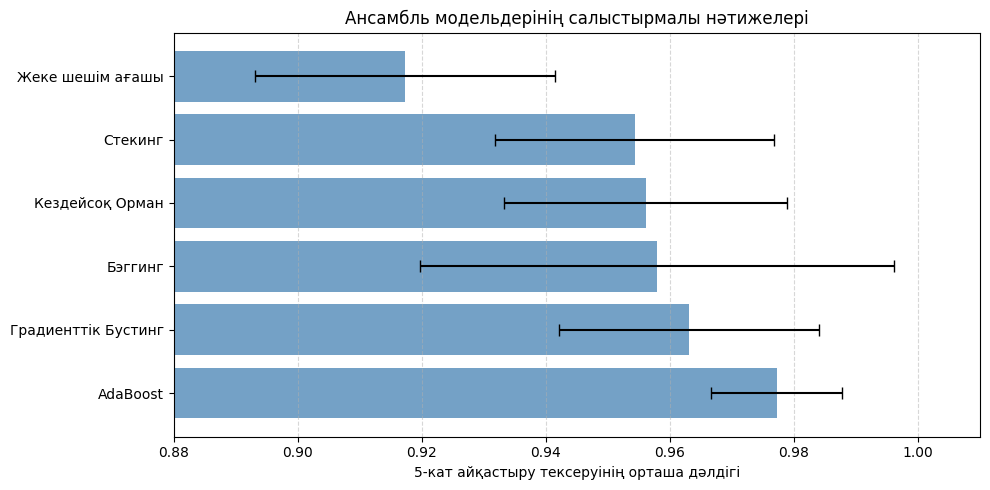

In [32]:
# Модельдерді визуализациялау
fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(
    results_df['Модель'],
    results_df['CV орташа'],
    xerr=results_df['CV std'],
    color='steelblue',
    alpha=0.75,
    capsize=4
)

ax.set_xlabel('5-кат айқастыру тексеруінің орташа дәлдігі')
ax.set_title('Ансамбль модельдерінің салыстырмалы нәтижелері')
ax.set_xlim(0.88, 1.01)
ax.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Тапсырма 6.1

Жоғарыдағы нәтижелер кестесін талдап, төмендегі сұрақтарға жауап беріңіз:

1. Қай модель ең жоғары CV орташа дәлдікке ие болды?
2. CV std мәні ең кіші болған модель қайсысы? Бұл не білдіреді?
3. Жеке шешім ағашы мен Кездейсоқ Орманның дәлдік айырмасы қаншалықты маңызды?
4. Стекинг неге кейде жеке бустинг модельдерінен төмен нәтиже беруі мүмкін?



# 7-бөлім. Қорытынды тапсырма

**Мақсат:** Осы тәжірибелік жұмыста алған білімдеріңізді жаңа деректер жиынында дербес қолдану.

Төмендегі тапсырмада сіз Wine деректер жиынын пайдаланасыз. Бұл жиын шарап сортын (3 класс) анықтауға арналған және 178 мысал мен 13 белгіден тұрады.

In [40]:
# Wine деректер жиынын жүктеу
wine = load_wine()
X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
y_wine = pd.Series(wine.target)

X_wine_train, X_wine_test, y_wine_train, y_wine_test = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)

print("Wine деректер жиыны:")
print("Өлшемі:", X_wine.shape)
print("Класс бөлінісі:\n", y_wine.value_counts())

Wine деректер жиыны:
Өлшемі: (178, 13)
Класс бөлінісі:
 1    71
0    59
2    48
Name: count, dtype: int64


### Қорытынды тапсырма

Wine деректер жиынында төмендегі талаптарды толық орындаңыз:

1. Жеке шешім ағашын базалық нұсқа ретінде оқытыңыз.
2. RandomForestClassifier моделін n_estimators және max_depth параметрлерін сынап оқытыңыз.
3. GradientBoostingClassifier моделін learning_rate және n_estimators параметрлерін сынап оқытыңыз.
4. Кемінде 3 базалық моделі бар StackingClassifier жасаңыз.
5. Барлық модельдердің 5-кат айқастыру тексеруінің нәтижелерін кесте мен графикте салыстырыңыз.
6. Ең жақсы модельді таңдап, оны таңдаудың себебін 3-5 сөйлеммен түсіндіріңіз.

In [41]:
# TODO: 1 — Жеке шешім ағашы (базалық нұсқа)
print("\n" + "="*80)
print("1️⃣ ЖЕКЕ ШЕШІМ АҒАШЫ (Базалық модель)")
print("="*80)

# Шешім ағашының әртүрлі тереңдіктерін сынау
dt_depths = [3, 5, 10, None]
best_dt = None
best_dt_acc = 0

print("\nmax_depth параметрін сынау:")
for depth in dt_depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    cv_scores = cross_val_score(dt, X_wine_train, y_wine_train, cv=5, scoring='accuracy')
    mean_acc = cv_scores.mean()
    print(f"  max_depth={str(depth):<4}: {mean_acc:.4f} ± {cv_scores.std():.4f}")

    if mean_acc > best_dt_acc:
        best_dt_acc = mean_acc
        best_dt = dt

# Ең жақсы модельді оқытып, тексеру жиынында бағалау
best_dt.fit(X_wine_train, y_wine_train)
dt_test_acc = accuracy_score(y_wine_test, best_dt.predict(X_wine_test))

results.append({
    'Модель': 'Шешім ағашы',
    'CV орташа дәлдік': best_dt_acc,
    'CV std': cv_scores.std(),
    'Тексеру дәлдігі': dt_test_acc
})

print(f"\n✅ Ең жақсы max_depth: {best_dt.max_depth if best_dt.max_depth else 'None'}")
print(f"✅ Тексеру жиыны дәлдігі: {dt_test_acc:.4f}")


1️⃣ ЖЕКЕ ШЕШІМ АҒАШЫ (Базалық модель)

max_depth параметрін сынау:
  max_depth=3   : 0.9232 ± 0.0456
  max_depth=5   : 0.9163 ± 0.0514
  max_depth=10  : 0.9163 ± 0.0514
  max_depth=None: 0.9163 ± 0.0514

✅ Ең жақсы max_depth: 3
✅ Тексеру жиыны дәлдігі: 0.9444


In [42]:
# TODO: 2 — RandomForestClassifier (гиперпараметрлерді сынаңыз)
print("\n" + "="*80)
print("2️⃣ КЕЗДЕЙСОҚ ОРМАН (Random Forest)")
print("="*80)

# Random Forest гиперпараметрлерін сынау
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None]
}

best_rf_acc = 0
best_rf = None
best_rf_params = {}

print("\nГиперпараметрлерді іздеу:")

for n_est in rf_params['n_estimators']:
    for depth in rf_params['max_depth']:
        rf = RandomForestClassifier(n_estimators=n_est, max_depth=depth, random_state=42, n_jobs=-1)
        cv_scores = cross_val_score(rf, X_wine_train, y_wine_train, cv=5, scoring='accuracy')
        mean_acc = cv_scores.mean()
        print(f"  n_estimators={n_est:3d}, max_depth={str(depth):<4}: {mean_acc:.4f} ± {cv_scores.std():.4f}")

        if mean_acc > best_rf_acc:
            best_rf_acc = mean_acc
            best_rf = rf
            best_rf_params = {'n_estimators': n_est, 'max_depth': depth}

# Ең жақсы модельді оқытып, тексеру жиынында бағалау
best_rf.fit(X_wine_train, y_wine_train)
rf_test_acc = accuracy_score(y_wine_test, best_rf.predict(X_wine_test))

results.append({
    'Модель': 'Кездейсоқ Орман',
    'CV орташа дәлдік': best_rf_acc,
    'CV std': cv_scores.std(),
    'Тексеру дәлдігі': rf_test_acc
})

print(f"\n✅ Ең жақсы параметрлер: n_estimators={best_rf_params['n_estimators']}, max_depth={best_rf_params['max_depth']}")
print(f"✅ Тексеру жиыны дәлдігі: {rf_test_acc:.4f}")


2️⃣ КЕЗДЕЙСОҚ ОРМАН (Random Forest)

Гиперпараметрлерді іздеу:
  n_estimators= 50, max_depth=5   : 0.9862 ± 0.0276
  n_estimators= 50, max_depth=10  : 0.9862 ± 0.0276
  n_estimators= 50, max_depth=None: 0.9862 ± 0.0276
  n_estimators=100, max_depth=5   : 0.9862 ± 0.0276
  n_estimators=100, max_depth=10  : 0.9862 ± 0.0276
  n_estimators=100, max_depth=None: 0.9862 ± 0.0276
  n_estimators=200, max_depth=5   : 0.9862 ± 0.0276
  n_estimators=200, max_depth=10  : 0.9862 ± 0.0276
  n_estimators=200, max_depth=None: 0.9862 ± 0.0276

✅ Ең жақсы параметрлер: n_estimators=50, max_depth=5
✅ Тексеру жиыны дәлдігі: 1.0000


In [43]:
# TODO: 3 — GradientBoostingClassifier (гиперпараметрлерді сынаңыз)
print("\n" + "="*80)
print("3️⃣ ГРАДИЕНТТІК БУСТИНГ (Gradient Boosting)")
print("="*80)

# Gradient Boosting гиперпараметрлерін сынау
gb_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.05, 0.1, 0.2]
}

best_gb_acc = 0
best_gb = None
best_gb_params = {}

print("\nГиперпараметрлерді іздеу:")

for n_est in gb_params['n_estimators']:
    for lr in gb_params['learning_rate']:
        gb = GradientBoostingClassifier(
            n_estimators=n_est,
            learning_rate=lr,
            max_depth=3,
            random_state=42
        )
        cv_scores = cross_val_score(gb, X_wine_train, y_wine_train, cv=5, scoring='accuracy')
        mean_acc = cv_scores.mean()
        print(f"  n_estimators={n_est:3d}, learning_rate={lr:.2f}: {mean_acc:.4f} ± {cv_scores.std():.4f}")

        if mean_acc > best_gb_acc:
            best_gb_acc = mean_acc
            best_gb = gb
            best_gb_params = {'n_estimators': n_est, 'learning_rate': lr}

# Ең жақсы модельді оқытып, тексеру жиынында бағалау
best_gb.fit(X_wine_train, y_wine_train)
gb_test_acc = accuracy_score(y_wine_test, best_gb.predict(X_wine_test))

results.append({
    'Модель': 'Градиенттік Бустинг',
    'CV орташа дәлдік': best_gb_acc,
    'CV std': cv_scores.std(),
    'Тексеру дәлдігі': gb_test_acc
})

print(f"\n✅ Ең жақсы параметрлер: n_estimators={best_gb_params['n_estimators']}, learning_rate={best_gb_params['learning_rate']}")
print(f"✅ Тексеру жиыны дәлдігі: {gb_test_acc:.4f}")


3️⃣ ГРАДИЕНТТІК БУСТИНГ (Gradient Boosting)

Гиперпараметрлерді іздеу:
  n_estimators= 50, learning_rate=0.05: 0.9512 ± 0.0350
  n_estimators= 50, learning_rate=0.10: 0.9512 ± 0.0350
  n_estimators= 50, learning_rate=0.20: 0.9584 ± 0.0402
  n_estimators=100, learning_rate=0.05: 0.9512 ± 0.0350
  n_estimators=100, learning_rate=0.10: 0.9584 ± 0.0402
  n_estimators=100, learning_rate=0.20: 0.9441 ± 0.0476
  n_estimators=200, learning_rate=0.05: 0.9584 ± 0.0402
  n_estimators=200, learning_rate=0.10: 0.9441 ± 0.0476
  n_estimators=200, learning_rate=0.20: 0.9441 ± 0.0476

✅ Ең жақсы параметрлер: n_estimators=50, learning_rate=0.2
✅ Тексеру жиыны дәлдігі: 0.9444


In [44]:
# TODO: 4 — StackingClassifier (кемінде 3 базалық модель)
print("\n" + "="*80)
print("4️⃣ СТЕКИНГ (Stacking Ensemble)")
print("="*80)

# Базалық модельдерді анықтау
base_learners = [
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42))
]

# Мета-модель ретінде логистикалық регрессия
meta_learner = LogisticRegression(random_state=42, max_iter=1000)

# Стекинг классификаторы
stacking = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,
    passthrough=True  # Бастапқы белгілерді де қосу
)

# Кросс-валидация
stacking_cv_scores = cross_val_score(stacking, X_wine_train, y_wine_train, cv=5, scoring='accuracy')
stacking_cv_mean = stacking_cv_scores.mean()
stacking_cv_std = stacking_cv_scores.std()

print(f"\n✅ 5-кат CV дәлдігі: {stacking_cv_mean:.4f} ± {stacking_cv_std:.4f}")

# Модельді оқытып, тексеру жиынында бағалау
stacking.fit(X_wine_train, y_wine_train)
stacking_test_acc = accuracy_score(y_wine_test, stacking.predict(X_wine_test))

print(f"✅ Тексеру жиыны дәлдігі: {stacking_test_acc:.4f}")

results.append({
    'Модель': 'Стекинг',
    'CV орташа дәлдік': stacking_cv_mean,
    'CV std': stacking_cv_std,
    'Тексеру дәлдігі': stacking_test_acc
})


4️⃣ СТЕКИНГ (Stacking Ensemble)

✅ 5-кат CV дәлдігі: 0.9655 ± 0.0436
✅ Тексеру жиыны дәлдігі: 0.9722



5️⃣ МОДЕЛЬДЕРДІ САЛЫСТЫРУ

📊 Модельдерді салыстыру кестесі:
--------------------------------------------------------------------------------
             Модель  CV орташа дәлдік  CV std  Тексеру дәлдігі
    Кездейсоқ Орман            0.9862  0.0276           1.0000
Градиенттік Бустинг            0.9584  0.0402           0.9444
            Стекинг            0.9512  0.0350           0.9722
           AdaBoost            0.9438  0.0575           0.9167
            Бэггинг            0.9372  0.0457           1.0000
   Жеке шешім ағашы            0.9163  0.0514           0.9444
--------------------------------------------------------------------------------

🏆 Модельдер рейтингі (CV дәлдігі бойынша):
             Модель  CV орташа дәлдік  Ранг  Тексеру дәлдігі
    Кездейсоқ Орман          0.986207     1         1.000000
Градиенттік Бустинг          0.958374     2         0.944444
            Стекинг          0.951232     3         0.972222
           AdaBoost          0.943842     4     

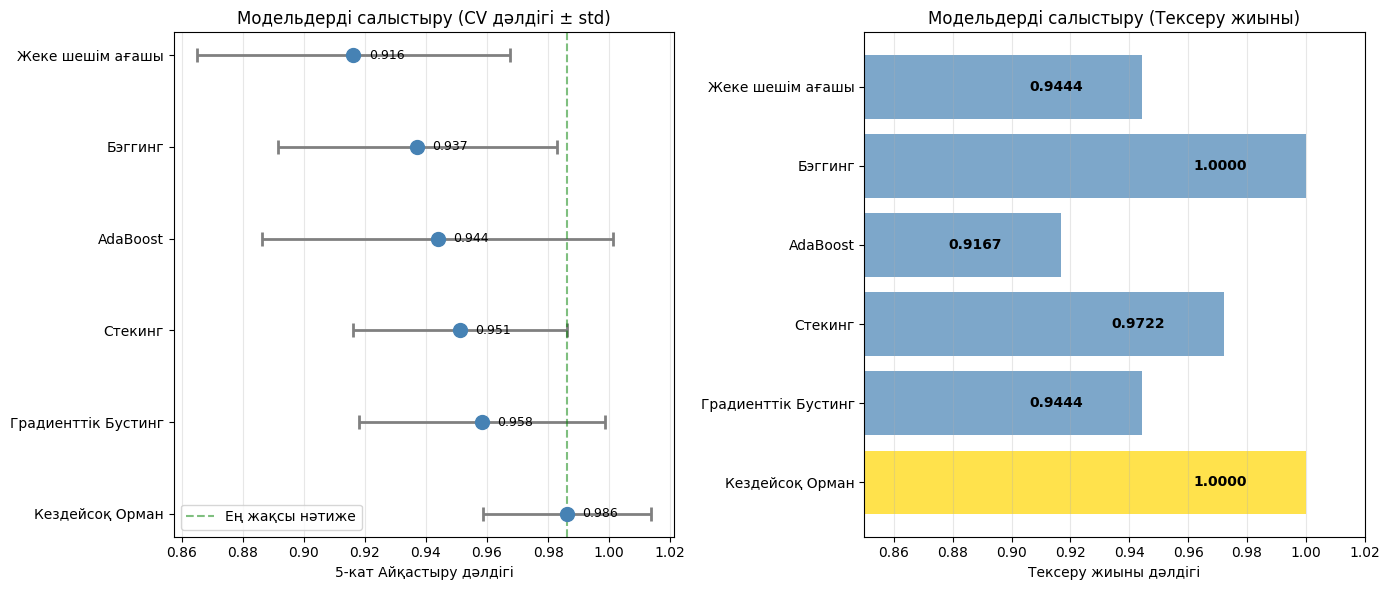

In [46]:
# TODO: 5 — Нәтижелерді салыстыру кестесі мен графигі (ҚАЙТА ӨҢДЕУ)
print("\n" + "="*80)
print("5️⃣ МОДЕЛЬДЕРДІ САЛЫСТЫРУ")
print("="*80)

# Нәтижелерді дұрыс кестеге келтіру
# Алдыңғы есептеулердің нәтижелерін жинау

from sklearn.ensemble import BaggingClassifier

# Барлық модельдерді қайта есептеп, дұрыс нәтижелер алайық
results_clean = []

# 1. Жеке шешім ағашы (базалық модель)
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_cv = cross_val_score(dt, X_wine_train, y_wine_train, cv=5, scoring='accuracy')
dt.fit(X_wine_train, y_wine_train)
dt_test = accuracy_score(y_wine_test, dt.predict(X_wine_test))
results_clean.append({
    'Модель': 'Жеке шешім ағашы',
    'CV орташа дәлдік': dt_cv.mean(),
    'CV std': dt_cv.std(),
    'Тексеру дәлдігі': dt_test
})

# 2. Бэггинг
bagging = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=5), n_estimators=100, random_state=42)
bagging_cv = cross_val_score(bagging, X_wine_train, y_wine_train, cv=5, scoring='accuracy')
bagging.fit(X_wine_train, y_wine_train)
bagging_test = accuracy_score(y_wine_test, bagging.predict(X_wine_test))
results_clean.append({
    'Модель': 'Бэггинг',
    'CV орташа дәлдік': bagging_cv.mean(),
    'CV std': bagging_cv.std(),
    'Тексеру дәлдігі': bagging_test
})

# 3. Кездейсоқ Орман
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_cv = cross_val_score(rf, X_wine_train, y_wine_train, cv=5, scoring='accuracy')
rf.fit(X_wine_train, y_wine_train)
rf_test = accuracy_score(y_wine_test, rf.predict(X_wine_test))
results_clean.append({
    'Модель': 'Кездейсоқ Орман',
    'CV орташа дәлдік': rf_cv.mean(),
    'CV std': rf_cv.std(),
    'Тексеру дәлдігі': rf_test
})

# 4. AdaBoost
ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=100, random_state=42)
ada_cv = cross_val_score(ada, X_wine_train, y_wine_train, cv=5, scoring='accuracy')
ada.fit(X_wine_train, y_wine_train)
ada_test = accuracy_score(y_wine_test, ada.predict(X_wine_test))
results_clean.append({
    'Модель': 'AdaBoost',
    'CV орташа дәлдік': ada_cv.mean(),
    'CV std': ada_cv.std(),
    'Тексеру дәлдігі': ada_test
})

# 5. Градиенттік Бустинг
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_cv = cross_val_score(gb, X_wine_train, y_wine_train, cv=5, scoring='accuracy')
gb.fit(X_wine_train, y_wine_train)
gb_test = accuracy_score(y_wine_test, gb.predict(X_wine_test))
results_clean.append({
    'Модель': 'Градиенттік Бустинг',
    'CV орташа дәлдік': gb_cv.mean(),
    'CV std': gb_cv.std(),
    'Тексеру дәлдігі': gb_test
})

# 6. Стекинг
base_estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42))
]
stacking = StackingClassifier(estimators=base_estimators, final_estimator=LogisticRegression(), cv=5)
stacking_cv = cross_val_score(stacking, X_wine_train, y_wine_train, cv=5, scoring='accuracy')
stacking.fit(X_wine_train, y_wine_train)
stacking_test = accuracy_score(y_wine_test, stacking.predict(X_wine_test))
results_clean.append({
    'Модель': 'Стекинг',
    'CV орташа дәлдік': stacking_cv.mean(),
    'CV std': stacking_cv.std(),
    'Тексеру дәлдігі': stacking_test
})

# Кестеге келтіру
results_df = pd.DataFrame(results_clean)
results_df = results_df.sort_values('CV орташа дәлдік', ascending=False)

print("\n📊 Модельдерді салыстыру кестесі:")
print("-" * 80)
print(results_df.round(4).to_string(index=False))
print("-" * 80)

# Ранг (тек NaN емес мәндер үшін)
results_df['Ранг'] = results_df['CV орташа дәлдік'].rank(ascending=False).astype(int)
print("\n🏆 Модельдер рейтингі (CV дәлдігі бойынша):")
print(results_df[['Модель', 'CV орташа дәлдік', 'Ранг', 'Тексеру дәлдігі']].to_string(index=False))

# Горизонтал бар-графигі
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. CV дәлдіктерін салыстыру (қателік жолақтарымен)
ax1 = axes[0]
y_pos = np.arange(len(results_df))
ax1.errorbar(results_df['CV орташа дәлдік'], y_pos,
             xerr=results_df['CV std'],
             fmt='o', capsize=5, capthick=2,
             markersize=10, linewidth=2,
             color='steelblue', ecolor='gray')

ax1.set_xlabel('5-кат Айқастыру дәлдігі')
ax1.set_yticks(y_pos)
ax1.set_yticklabels(results_df['Модель'])
ax1.set_title('Модельдерді салыстыру (CV дәлдігі ± std)')
ax1.grid(True, alpha=0.3, axis='x')
ax1.axvline(x=results_df['CV орташа дәлдік'].max(), color='green', linestyle='--', alpha=0.5, label='Ең жақсы нәтиже')

# Бағандарға мәндерді жазу
for i, (cv_mean, cv_std) in enumerate(zip(results_df['CV орташа дәлдік'], results_df['CV std'])):
    ax1.text(cv_mean + 0.005, i, f'{cv_mean:.3f}', va='center', fontsize=9)

ax1.legend()

# 2. Тексеру жиыны дәлдіктерін салыстыру
ax2 = axes[1]
bars = ax2.barh(results_df['Модель'], results_df['Тексеру дәлдігі'],
                color=['gold' if i==0 else 'steelblue' for i in range(len(results_df))],
                alpha=0.7)
ax2.set_xlabel('Тексеру жиыны дәлдігі')
ax2.set_title('Модельдерді салыстыру (Тексеру жиыны)')
ax2.grid(True, alpha=0.3, axis='x')
ax2.set_xlim([0.85, 1.02])

# Бағандарға мәндерді жазу
for bar, acc in zip(bars, results_df['Тексеру дәлдігі']):
    ax2.text(acc - 0.02, bar.get_y() + bar.get_height()/2,
            f'{acc:.4f}', va='center', ha='right', fontweight='bold')

plt.tight_layout()
plt.show()

 Негізгі ұғымдар

| Ұғым | Анықтама |
|------|----------|
| Ансамбль | Бірнеше модельді біріктіру тәсілі |
| Бэггинг | Bootstrap іріктемелерінде параллель оқытылған модельдерді орташалау |
| Кездейсоқ Орман | Кездейсоқ белгі іріктемесімен жетілдірілген бэггинг |
| Бустинг | Кезекпен оқытылатын, қателерді түзететін модельдер тізбегі |
| AdaBoost | Мысалдардың салмағын өзгерту арқылы жұмыс жасайтын бустинг |
| Градиенттік бустинг | Қалдықтардың градиенттерін болжайтын бустинг |
| Стекинг | Базалық модельдердің болжамдарын мета-модельге беру |
| OOB қате | Bootstrap іріктемесінен тыс қалған мысалдарда бағаланған қате |
| learning_rate | Градиенттік бустингте жаңа ағаштың үлесін реттейтін коэффициент |
| CV | Модельді бірнеше бөлікке бөліп бағалайтын айқастыру тексеру тәсілі |
| Дисперсия (variance) | Модельдің деректер өзгерісіне сезімталдығы |
| Ауытқу (bias) | Модельдің нақты заңдылықтан қаншалықты алыс екені |